# Instacart Grocery Reorder Prediction with User Segmentation and Market Basket Analysis
Team 404 not Found

# 1. Executive Summary
### Decisions to be Impacted

This project aims to support **product recommendation** and **basket completion decisions** in an online grocery platform.

The outputs of this project can be leveraged to:

- **Next-Order Prediction**
  - Predict which products a user is likely to purchase in their next order

- **Top-K Recommendation Optimization**
  - Optimize Top-K recommendation strategies for basket construction

- **Cross-Sell & Bundling**
  - Identify cross-sell and bundling opportunities across product categories

- **User Segmentation**
  - Support segmentation-based recommendation policies for personalized experiences

### Business Value

The project delivers value across three key dimensions:

- **Conversion Rate Improvement**
  - By predicting next-order products, the system surfaces highly relevant items
  - This increases the probability of add-to-cart and overall conversion

- **Basket Size Expansion (Cross-Sell & Bundling)**
  - Association patterns across product categories enable targeted bundling strategies  
    *(e.g., yogurt + granola)*
  - This drives higher average order value (AOV)

- **User Personalization**
  - User segmentation supports differentiated recommendation strategies, such as:
    - High-frequency, loyal users → efficiency-driven recommendations (reorder-focused)
    - Low-frequency, exploratory users → discovery-driven recommendations

### Data assets
We use the **Instacart Online Grocery Dataset**, which contains:

- **Scale**: 3.4M orders, 33.7M product-level purchase records, 206K users  

The dataset is originally organized into multiple tables:

- **orders**
  - User order sequence and timestamps  

- **order_products__prior / order_products__train**
  - Product-level purchase records  

- **products / aisles / departments**
  - Product hierarchy information  

To facilitate modeling, we consolidate these tables into a unified **transaction-level table (`op_all`)**, where:

- Each row represents **one product purchased in one order by one user**

In [67]:
import os
import warnings

import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

In [68]:
# Download and load raw Instacart tables
path = kagglehub.dataset_download(
    "yasserh/instacart-online-grocery-basket-analysis-dataset"
)
print("Dataset downloaded to:", path)
BASE_PATH = path

print("\nFiles in dataset directory:")
for f in os.listdir(BASE_PATH):
    print(f)

orders = pd.read_csv(os.path.join(BASE_PATH, "orders.csv"))
prior = pd.read_csv(os.path.join(BASE_PATH, "order_products__prior.csv"))
train_op = pd.read_csv(os.path.join(BASE_PATH, "order_products__train.csv"))
products = pd.read_csv(os.path.join(BASE_PATH, "products.csv"))
aisles = pd.read_csv(os.path.join(BASE_PATH, "aisles.csv"))
departments = pd.read_csv(os.path.join(BASE_PATH, "departments.csv"))


Dataset downloaded to: /Users/bettinabopeng/.cache/kagglehub/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/versions/1

Files in dataset directory:
products.csv
orders.csv
order_products__train.csv
departments.csv
aisles.csv
order_products__prior.csv


In [69]:
print(orders.head())
print(prior.head())
print(train_op.head())
print(products.head())
print(aisles.head())
print(departments.head())
print(orders.describe())
print(prior.describe())
print(train_op.describe())

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0
   order_id  product_id  add_to_cart_order  r

## 2. Data Preprocessing

We begin by cleaning and consolidating the dataset to ensure consistency for downstream modeling.

First, we remove invalid product categories labeled as *"missing"*, including 1 aisle, 1 department, and 1,258 related products. This results in the removal of 69,145 rows from the `prior` set and 8,251 rows from the `train` set.

Next, we examine NA values. Only one column, `days_since_prior_order`, contains NA entries (206,209 in total). These correspond exactly to each user’s first order, where no prior order exists. Since this is structural rather than dirty data, we fill these values with 0 for modeling convenience.

A key challenge of this dataset is its original train/test split. In the Kaggle setup, test users’ final orders do not include product-level labels, making the split unsuitable for supervised learning. Although test orders account for only 2.19% at the order level, they represent 36.37% of users and contribute 36.36% of historical purchase records. Therefore, removing test users would lead to substantial information loss.

To address this, we first combine `order_products__prior` and `order_products__train` into a unified transaction table, `op_all`, and enrich it by joining metadata from `orders`, `products`, `aisles`, and `departments`. After merging, each row in `op_all` represents one product purchased by one user in one order, along with user information, order sequence, original `eval_set`, and product hierarchy.

We then redefine the prediction task. For each user, the last order that still contains product-level information is treated as the target, while all preceding orders are considered historical data. This allows us to construct a consistent supervised learning framework without discarding valuable user behavior.

The resulting dataset contains 206,209 target orders (131,186 from the original train set and 75,023 from prior), with 2,153,402 rows in the target set and 31,588,308 rows in the history set.

Finally, we conduct exploratory analysis on key variables such as user activity (total orders), basket size, candidate size (unique products per user), and user–product interaction frequency. All distributions exhibit strong long-tail behavior, with no clear evidence of erroneous values or abnormal outliers. Therefore, no outlier removal is applied, and analysis is performed using quantiles and log-scale transformations.

Overall, the consolidated dataset `op_all` serves as the foundation for subsequent EDA, feature engineering, and modeling.

In [70]:
# Detect and remove Missing-value
def is_literal_missing(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().eq("missing")

product_name_missing_mask = is_literal_missing(products["product_name"])
aisle_name_missing_mask = is_literal_missing(aisles["aisle"])
department_name_missing_mask = is_literal_missing(departments["department"])

print("\nLiteral 'missing' string check (raw dimension tables):")
print("  products with product_name == 'missing':", int(product_name_missing_mask.sum()))
print("  aisles with aisle == 'missing':", int(aisle_name_missing_mask.sum()))
print("  departments with department == 'missing':", int(department_name_missing_mask.sum()))

missing_product_ids = set(products.loc[product_name_missing_mask, "product_id"])
missing_aisle_ids = set(aisles.loc[aisle_name_missing_mask, "aisle_id"])
missing_department_ids = set(departments.loc[department_name_missing_mask, "department_id"])

# Also remove products whose linked aisle/department is literally named "missing"
product_missing_meta_mask = (
    products["product_id"].isin(missing_product_ids)
    | products["aisle_id"].isin(missing_aisle_ids)
    | products["department_id"].isin(missing_department_ids)
)

print("  products removed due to literal 'missing' product/aisle/department metadata:",
      int(product_missing_meta_mask.sum()))
print("  prior rows linked to removed products:",
      int(prior["product_id"].isin(set(products.loc[product_missing_meta_mask, "product_id"])).sum()))
print("  train rows linked to removed products:",
      int(train_op["product_id"].isin(set(products.loc[product_missing_meta_mask, "product_id"])).sum()))

removed_product_ids = set(products.loc[product_missing_meta_mask, "product_id"])

products = products.loc[~product_missing_meta_mask].copy()
aisles = aisles.loc[~aisle_name_missing_mask].copy()
departments = departments.loc[~department_name_missing_mask].copy()
prior = prior.loc[~prior["product_id"].isin(removed_product_ids)].copy()
train_op = train_op.loc[~train_op["product_id"].isin(removed_product_ids)].copy()

# Missing-value diagnostics (raw tables, after removing literal "missing" strings)
# Note: In Instacart, days_since_prior_order is NA for a user's first order.
print("\nMissing-value check (raw tables):")
print("  shape after removing literal 'missing' metadata:")
print("    orders:", orders.shape)
print("    prior:", prior.shape)
print("    train_op:", train_op.shape)
print("    products:", products.shape)
print("    aisles:", aisles.shape)
print("    departments:", departments.shape)
print("  orders missing counts:")
print(orders.isna().sum().to_string())

# Focused check for the known NA pattern
na_days = int(orders["days_since_prior_order"].isna().sum())
first_orders = orders[orders["order_number"] == 1]
na_days_first = int(first_orders["days_since_prior_order"].isna().sum())
print("\n  days_since_prior_order NA count:", na_days)
print("  NA among first orders (order_number==1):", na_days_first)
print("  first orders total:", int(first_orders.shape[0]))

print("\n  prior missing counts:")
print(prior.isna().sum().to_string())
print("\n  train_op missing counts:")
print(train_op.isna().sum().to_string())

# For EDA convenience, treat first-order NA as 0 days since prior order
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)



Literal 'missing' string check (raw dimension tables):
  products with product_name == 'missing': 0
  aisles with aisle == 'missing': 1
  departments with department == 'missing': 1
  products removed due to literal 'missing' product/aisle/department metadata: 1258
  prior rows linked to removed products: 69145
  train rows linked to removed products: 8251

Missing-value check (raw tables):
  shape after removing literal 'missing' metadata:
    orders: (3421083, 7)
    prior: (32365344, 4)
    train_op: (1376366, 4)
    products: (48430, 4)
    aisles: (133, 2)
    departments: (20, 2)
  orders missing counts:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209

  days_since_prior_order NA count: 206209
  NA among first orders (order_number==1): 206209
  first orders total: 206209

  prior missing counts:
ord

In [71]:
# 3. Original Kaggle split inspection
# 3.1 Order-level share by original eval_set
order_counts = orders["eval_set"].value_counts(dropna=False)
print("\nOrders by eval_set:")
print(order_counts)
print("\nOrders share:")
print((order_counts / len(orders)).round(4))

#
# 3.2 User-level share by final eval_set
user_eval = orders.groupby("user_id")["eval_set"].agg(lambda s: set(s)).reset_index()

# In the standard Instacart setup, a user's final order determines whether the user belongs to train or test.
# We identify this robustly by taking each user's last order.
last_order = orders.sort_values(["user_id", "order_number"]).groupby("user_id").tail(1)
user_counts = last_order["eval_set"].value_counts()
print("\nUsers by final eval_set (based on last order):")
print(user_counts)
print("\nUsers share:")
print((user_counts / user_counts.sum()).round(4))

# 3.3 Purchase-row contribution: how many prior rows come from train users vs test users
test_users = set(last_order.loc[last_order["eval_set"] == "test", "user_id"])
train_users = set(last_order.loc[last_order["eval_set"] == "train", "user_id"])

# Attach user_id to prior rows through orders.csv
prior_u = prior.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
prior_u = prior_u.dropna(subset=["user_id"])
prior_u["user_id"] = prior_u["user_id"].astype(int)

prior_test_rows = (prior_u["user_id"].isin(test_users)).sum()
prior_train_rows = (prior_u["user_id"].isin(train_users)).sum()

print("\nPrior rows share by user group:")
print("  prior total rows:", len(prior_u))
print("  prior rows from train users:", prior_train_rows, f"({prior_train_rows/len(prior_u):.4%})")
print("  prior rows from test users :", prior_test_rows,  f"({prior_test_rows/len(prior_u):.4%})")

# Do the same for train order-products rows (these should correspond to train users)
train_u = train_op.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
print("\nTrain order_products rows:", len(train_u))
print("Unique users in train_op:", train_u['user_id'].nunique())



Orders by eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Orders share:
eval_set
prior    0.9397
train    0.0384
test     0.0219
Name: count, dtype: float64

Users by final eval_set (based on last order):
eval_set
train    131209
test      75000
Name: count, dtype: int64

Users share:
eval_set
train    0.6363
test     0.3637
Name: count, dtype: float64

Prior rows share by user group:
  prior total rows: 32365344
  prior rows from train users: 20597672 (63.6411%)
  prior rows from test users : 11767672 (36.3589%)

Train order_products rows: 1376366
Unique users in train_op: 131186


In [72]:
# outlier inspection
def plot_hist_with_quantiles(series: pd.Series, title: str, xlabel: str, bins: int = 80, logy: bool = True):
    s = pd.Series(series).dropna().astype(float)
    qs = s.quantile([0.50, 0.90, 0.99]).to_dict()

    print(f"\n{title}")
    print("  count:", int(s.shape[0]))
    print("  quantiles:", {k: float(v) for k, v in qs.items()})

    plt.figure(figsize=(9, 4))
    plt.hist(s.values, bins=bins)
    if logy:
        plt.yscale("log")

    ymax = plt.ylim()[1]
    for p in [0.50, 0.90, 0.99]:
        v = qs[p]
        plt.axvline(v, linestyle="--")
        plt.text(v, ymax * 0.85, f"p{int(p*100)}", rotation=90, va="top")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    return qs

In [73]:
# Build a unified purchase-level table (prior + train)
op_all = pd.concat(
    [prior.assign(source="prior"), train_op.assign(source="train")],
    ignore_index=True,
)

# Attach user/order metadata to each purchased row
op_all = op_all.merge(
    orders[["order_id", "user_id", "order_number", "eval_set"]],
    on="order_id",
    how="left",
)

# Attach product hierarchy metadata from the beginning
# This keeps the unified purchase table aligned with downstream EDA and future modeling.
op_all = op_all.merge(
    products[["product_id", "aisle_id", "department_id"]],
    on="product_id",
    how="left",
)
op_all = op_all.merge(
    aisles[["aisle_id", "aisle"]],
    on="aisle_id",
    how="left",
)
op_all = op_all.merge(
    departments[["department_id", "department"]],
    on="department_id",
    how="left",
)

op_all = op_all.dropna(subset=["user_id"]).copy()
op_all["user_id"] = op_all["user_id"].astype(np.uint32)


## -----------------------------------------------------
# 5.1 Preview of the fully merged purchase-level table
# Each row in op_all is one purchased product within one order.
# Columns:
#   order_id                : unique order identifier
#   product_id              : purchased product identifier
#   add_to_cart_order       : position of the product within the cart/order
#   reordered               : 1 if this product had been purchased by the same user before, else 0
#   source                  : whether this purchase row originally came from the Kaggle prior set or train set
#   user_id                 : unique user identifier
#   order_number            : sequential order index for that user (1 = first order)
#   eval_set                : original Kaggle split label of the order (prior / train / test)
#   aisle_id                : aisle/category identifier from products.csv
#   department_id           : department identifier from products.csv
#   aisle                   : aisle name
#   department              : department name
#
## -----------------------------------------------------

print("\nHead of merged purchase-level table op_all:")
print(op_all.head(10).to_string(index=False))

# 5.2 Coverage check after merging raw purchase tables
print("\nUnified scope (ALL users):")
print("  orders:", orders.shape)
print("  op_all (prior+train purchases):", op_all.shape)
print("  unique users in orders:", orders["user_id"].nunique())
print("  unique users with purchases in op_all:", op_all["user_id"].nunique())


Head of merged purchase-level table op_all:
 order_id  product_id  add_to_cart_order  reordered source  user_id  order_number eval_set  aisle_id  department_id                      aisle department
        2       33120                  1          1  prior   202279             3    prior        86             16                       eggs dairy eggs
        2       28985                  2          1  prior   202279             3    prior        83              4           fresh vegetables    produce
        2        9327                  3          0  prior   202279             3    prior       104             13          spices seasonings     pantry
        2       45918                  4          1  prior   202279             3    prior        19             13              oils vinegars     pantry
        2       30035                  5          0  prior   202279             3    prior        17             13         baking ingredients     pantry
        2       17794          

### Exploratory Data Analysis (EDA)

After data cleaning, consolidation, and task redefinition, we conduct exploratory data analysis (EDA) to better understand the structure of the dataset and inform downstream modeling decisions.

This section aims to answer the following questions:

- Do users exhibit significant heterogeneity in activity and purchase breadth?
- How do basket size, purchase frequency, and recency relate to next-order prediction?
- Are there clear temporal patterns in user behavior?
- Do products and categories exhibit strong head–tail structures and heterogeneous reorder behavior?

Accordingly, the following analysis is organized into four perspectives:

1. **User-level**: user activity and purchase breadth  
2. **Order / user–product level**: basket size, frequency, and recency  
3. **Temporal behavior**: time-of-day and inter-order intervals  
4. **Product and category level**: popularity and reorder patterns  

These insights directly support feature engineering, candidate generation, and model design.

#### Figure 1: Per-user total orders

This figure shows the distribution of total orders per user (`u_total_orders`).

- The distribution is clearly long-tailed: most users have relatively few orders, while a small fraction are highly active  
- There are noticeable local peaks rather than a smooth decay, indicating concentration at certain order counts  
- A spike at 100 is observed due to truncation, as `order_number` is capped at 100 in the dataset  

This indicates strong heterogeneity in user activity. User activeness is an important dimension and should be considered in modeling, especially when differentiating between light and heavy users.



Per-user total orders distribution (ALL users)
  count: 206209
  quantiles: {0.5: 10.0, 0.9: 38.0, 0.99: 89.0}


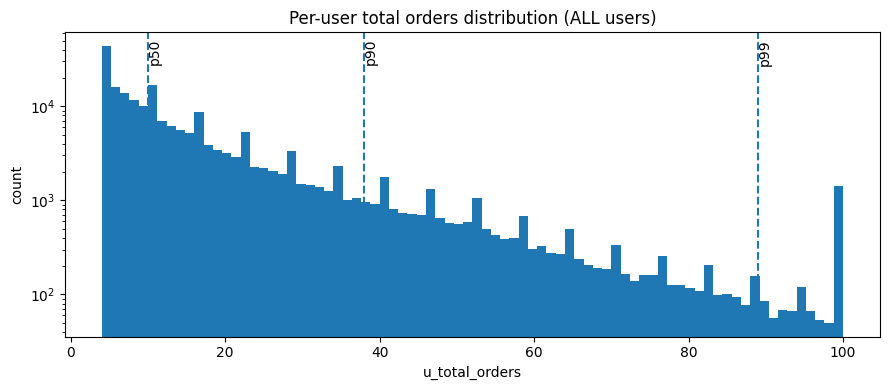


User coverage by minimum order threshold:
  users with >= 2 orders: 206209 (100.00%)
  users with >= 3 orders: 206209 (100.00%)
  users with >= 4 orders: 206209 (100.00%)
  users with >= 5 orders: 182223 (88.37%)
  users with >= 10 orders: 110728 (53.70%)
  users with >= 20 orders: 53931 (26.15%)
  users with >= 30 orders: 30677 (14.88%)

Filter: disabled for now; keep ALL users
  orders (all users): (3421083, 7)
  purchases op_all (all users): (33741710, 12)


In [74]:
# User-order-count inspection and current filtering choice
u_total_orders = orders.groupby("user_id")["order_number"].max()
qs = plot_hist_with_quantiles(
    u_total_orders,
    title="Per-user total orders distribution (ALL users)",
    xlabel="u_total_orders",
    bins=80,
    logy=True,
)

# Threshold diagnostics: how much user coverage remains under different minimum-order cutoffs
print("\nUser coverage by minimum order threshold:")
for th in [2, 3, 4, 5, 10, 20, 30]:
    kept = int((u_total_orders >= th).sum())
    print(f"  users with >= {th} orders: {kept} ({kept/u_total_orders.shape[0]:.2%})")

# Current choice: do not apply a minimum-order filter yet; keep all users for EDA
print("\nFilter: disabled for now; keep ALL users")
orders_f = orders.copy()
op_f = op_all.copy()
print("  orders (all users):", orders_f.shape)
print("  purchases op_all (all users):", op_f.shape)

In [75]:
# Define a new target order and split purchases into target vs history
# For each user, find the maximum order_number among orders that appear in op_f.
user_last_avail = (
    op_f.groupby("user_id")["order_number"].max().rename("target_order_number").reset_index()
)

# Map that order_number back to a concrete target order_id (if ties exist, keep the max order_id)
target_orders = orders_f.merge(user_last_avail, on="user_id", how="inner")
target_orders = target_orders[target_orders["order_number"] == target_orders["target_order_number"]].copy()
target_orders = target_orders.sort_values(["user_id", "order_id"]).groupby("user_id").tail(1)

target_order_id_by_user = target_orders.set_index("user_id")["order_id"].to_dict()

print("\nNew target orders (last available with details) AFTER filtering:")
print("  users with a target order:", len(target_order_id_by_user))
print("  target orders eval_set breakdown:")
print(target_orders["eval_set"].value_counts(dropna=False))

# Split the unified purchase table into target-order rows vs history rows
user_target_series = pd.Series(target_order_id_by_user)
op_f = op_f.copy()
op_f["target_order_id"] = op_f["user_id"].map(user_target_series)
op_f["is_target_order"] = (op_f["order_id"] == op_f["target_order_id"])

target_op = op_f[op_f["is_target_order"]].copy()
history_op = op_f[~op_f["is_target_order"]].copy()

print("  target_op rows:", target_op.shape)
print("  history_op rows:", history_op.shape)

# Users eligible for supervised learning under this split (must have at least one history order)
user_hist_orders = history_op.groupby("user_id")["order_id"].nunique()
eligible_users = user_hist_orders[user_hist_orders >= 1].index
print("  users with >=1 history order:", int(eligible_users.shape[0]))



New target orders (last available with details) AFTER filtering:
  users with a target order: 206209
  target orders eval_set breakdown:
eval_set
train    131186
prior     75023
Name: count, dtype: int64
  target_op rows: (2153402, 14)
  history_op rows: (31588308, 14)
  users with >=1 history order: 206209


We defined the last order that still has product-level details as the target order for each user, and treated all earlier orders as history.

The resulting split is:
	•	target_orders: 206,209 orders in total
	•	131,186 from the original train set
	•	75,023 from the original prior set
	•	target_op: 2,153,402 rows
	•	history_op: 31,588,308 rows

In [76]:
# Outlier inspection 
# We inspect extreme values in several key behavioral variables.
# At this stage, we do not remove any observations because most extremes reflect natural long-tail behavior rather than obvious data errors.

def print_outlier_summary(series: pd.Series, name: str):
    s = pd.Series(series).dropna().astype(float)
    q = s.quantile([0.50, 0.90, 0.95, 0.99, 0.999]).to_dict()
    print(f"\nOutlier inspection: {name}")
    print("  count:", int(s.shape[0]))
    print("  min/max:", float(s.min()), float(s.max()))
    print("  quantiles:", {k: float(v) for k, v in q.items()})

# 1) user total orders
print_outlier_summary(u_total_orders, "u_total_orders")

# 2) target basket size
bs_target_for_outlier = target_op.groupby("order_id")["product_id"].size()
print_outlier_summary(bs_target_for_outlier, "target basket size")

# 3) per-user unique products in history (candidate size)
h_u_unique_for_outlier = history_op.groupby("user_id")["product_id"].nunique()
print_outlier_summary(h_u_unique_for_outlier, "history unique products per user")

# 4) user-product purchase count
up_buy_cnt_for_outlier = history_op.groupby(["user_id", "product_id"])["order_id"].size()
print_outlier_summary(up_buy_cnt_for_outlier, "up_buy_cnt")

# 5) days_since_prior_order (note: this field is top-coded at 30 in the Instacart dataset)
days_since_series = orders_f["days_since_prior_order"]
print_outlier_summary(days_since_series, "days_since_prior_order")



Outlier inspection: u_total_orders
  count: 206209
  min/max: 4.0 100.0
  quantiles: {0.5: 10.0, 0.9: 38.0, 0.95: 52.0, 0.99: 89.0, 0.999: 100.0}

Outlier inspection: target basket size
  count: 206209
  min/max: 1.0 80.0
  quantiles: {0.5: 9.0, 0.9: 21.0, 0.95: 26.0, 0.99: 36.0, 0.999: 51.0}

Outlier inspection: history unique products per user
  count: 206209
  min/max: 1.0 725.0
  quantiles: {0.5: 46.0, 0.9: 137.0, 0.95: 177.0, 0.99: 264.0, 0.999: 386.0}

Outlier inspection: up_buy_cnt
  count: 12945171
  min/max: 1.0 99.0
  quantiles: {0.5: 1.0, 0.9: 5.0, 0.95: 8.0, 0.99: 18.0, 0.999: 39.0}

Outlier inspection: days_since_prior_order
  count: 3421083
  min/max: 0.0 30.0
  quantiles: {0.5: 7.0, 0.9: 30.0, 0.95: 30.0, 0.99: 30.0, 0.999: 30.0}


#### Figure 2: Per-user unique products (candidate size)

This figure shows the number of unique products each user has purchased historically.

- The distribution is also long-tailed: most users have moderate purchase breadth, while a small number have very large candidate sets  
- The median is 46, while higher percentiles reach 137 (p90) and 264 (p99)  
- No artificial truncation is observed, suggesting this reflects genuine behavioral variation  

This implies substantial heterogeneity in user “exploration breadth.” Candidate size directly affects the complexity of recommendation, making it an important factor in model design.



Figure 2: Per-user unique products in HISTORY (candidate size)
  count: 206209
  quantiles: {0.5: 46.0, 0.9: 137.0, 0.99: 264.0}


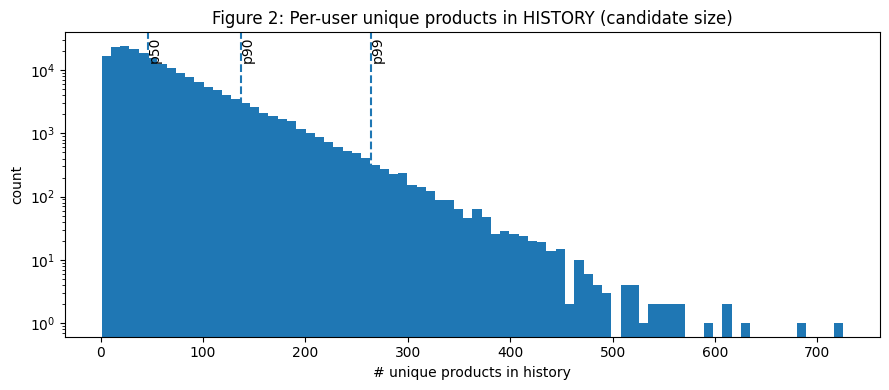

{0.5: 46.0, 0.9: 137.0, 0.99: 264.0}

In [77]:
# 9.2 Figure 2: Candidate size per user in history (unique products)
h_u_unique = history_op.groupby("user_id")["product_id"].nunique()
plot_hist_with_quantiles(
    h_u_unique,
    title="Figure 2: Per-user unique products in HISTORY (candidate size)",
    xlabel="# unique products in history",
    bins=80,
    logy=True,
)

#### Figure 3: Target-order basket size

This figure shows the distribution of basket size per target order, with a log-scaled y-axis.

- The distribution is long-tailed: most orders are small, but large baskets do exist  
- The median is 9 and the mean is 10.44, indicating right-skewness due to large orders  
- The p90 is around 21, meaning only a small portion of orders are very large  

This suggests that typical basket size lies in the range of 5–15 items. It supports setting Top-K recommendation around ~15, while still accounting for users with larger baskets.


Figure 3: Target order basket size summary
  mean=10.44, median=9.00, p90=21.00


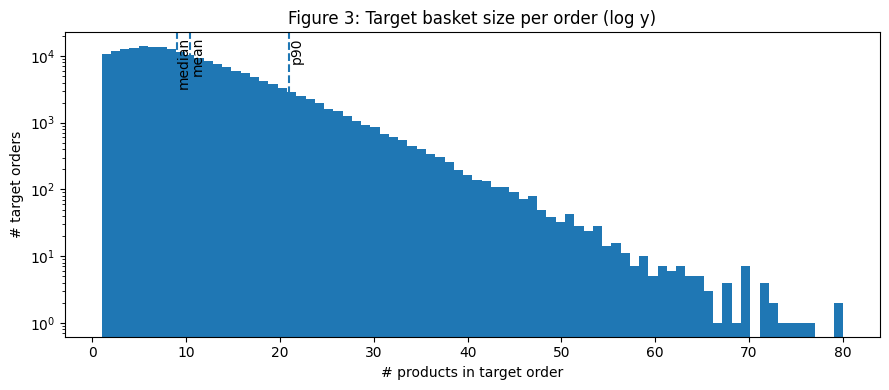

In [78]:
# 9.1 Figure 3: Target-order basket size distribution (supports Top-K choice)
# Basket size for each target order
bs_target = target_op.groupby("order_id")["product_id"].size().astype(float)
mean_bs = float(bs_target.mean())
median_bs = float(bs_target.median())
p90_bs = float(bs_target.quantile(0.90))

print("\nFigure 3: Target order basket size summary")
print(f"  mean={mean_bs:.2f}, median={median_bs:.2f}, p90={p90_bs:.2f}")

plt.figure(figsize=(9, 4))
plt.hist(bs_target.values, bins=80)
plt.yscale("log")
plt.axvline(mean_bs, linestyle="--")
plt.axvline(median_bs, linestyle="--")
plt.axvline(p90_bs, linestyle="--")

# Add simple reference labels
ymax = plt.ylim()[1]
plt.text(mean_bs, ymax * 0.85, "mean", rotation=90, va="top")
plt.text(median_bs, ymax * 0.85, "median", rotation=90, va="top")
plt.text(p90_bs, ymax * 0.85, "p90", rotation=90, va="top")

plt.title("Figure 3: Target basket size per order (log y)")
plt.xlabel("# products in target order")
plt.ylabel("# target orders")
plt.tight_layout()
plt.show()


#### Figure 4: User–product purchase frequency (up_buy_cnt)

This figure shows how many times each (user, product) pair appears in historical data.

- The distribution is extremely long-tailed: most pairs occur only 1–2 times  
- Frequency drops rapidly as count increases  
- A small number of pairs are highly frequent (>20 times), indicating strong habitual behavior  

This indicates that repeated purchases are concentrated in a small subset of user–product pairs. Historical frequency is therefore a strong predictive signal and should be included as a key feature.


Figure 4: up_buy_cnt tail
  #(user,product) pairs with up_buy_cnt > 20: 98635


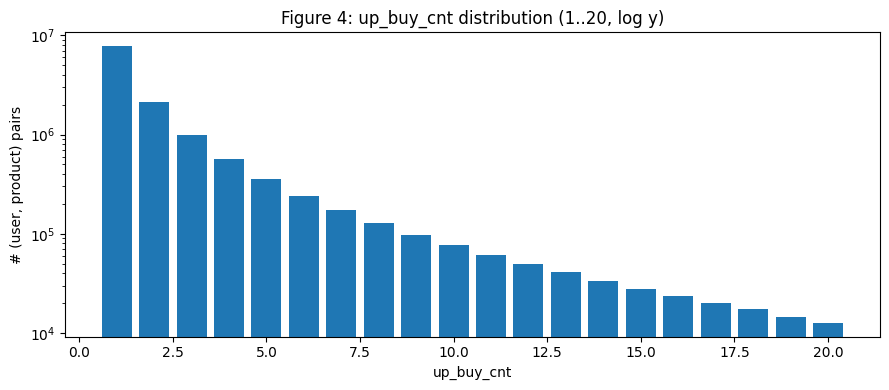

In [79]:
# 9.3 Figure 4: User-product purchase frequency distribution (up_buy_cnt)
up_buy_cnt = history_op.groupby(["user_id", "product_id"])["order_id"].size()
vc = up_buy_cnt.value_counts()
xs = list(range(1, 21))
ys = [int(vc.get(i, 0)) for i in xs]
ys_tail = int(vc[vc.index > 20].sum()) if (vc.index > 20).any() else 0

print("\nFigure 4: up_buy_cnt tail")
print("  #(user,product) pairs with up_buy_cnt > 20:", ys_tail)

plt.figure(figsize=(9, 4))
plt.bar(xs, ys)
plt.yscale("log")
plt.title("Figure 4: up_buy_cnt distribution (1..20, log y)")
plt.xlabel("up_buy_cnt")
plt.ylabel("# (user, product) pairs")
plt.tight_layout()
plt.show()


#### Figure 5: Recency vs. purchase probability

This figure shows how the number of orders since last purchase affects the probability of repurchase.

- There is a clear monotonic decreasing trend  
- The probability is highest at `orders_since_last = 1` (~28%)  
- It decays rapidly and approaches ~1% after 20+ orders  

This demonstrates that recency is a highly predictive feature. Recently purchased items are significantly more likely to be reordered and should be explicitly modeled.


Figure 5: orders_since_last bins vs purchase probability
  bin  purchase_prob  n_pairs
    0            NaN        0
    1       0.279966  2119001
    2       0.162442  1510570
    3       0.111735  1203557
    4       0.083656   944551
    5       0.067383   767970
 6-10       0.044972  2416885
11-20       0.023702  2066741
  >20       0.010519  1915896


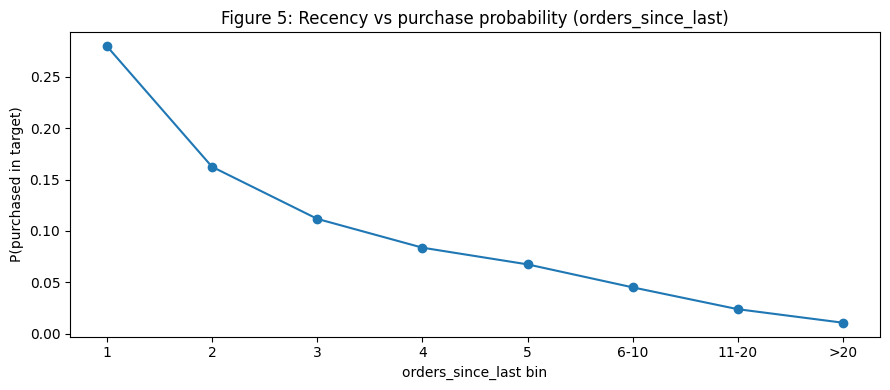

In [80]:
# 9.4 Figure 5: Recency vs purchase probability
# Build the binary label: whether a (user, product) pair appears in the target order
label_df = target_op[["user_id", "product_id"]].drop_duplicates().copy()
label_df["label"] = 1

# For each (user, product) pair in history, compute the last observed order_number
up_last = (
    history_op.groupby(["user_id", "product_id"])["order_number"].max().rename("up_last_order").reset_index()
)

# Target order_number for each user
user_target_on = target_orders[["user_id", "target_order_number"]].copy()

rec = up_last.merge(user_target_on, on="user_id", how="left")
rec["orders_since_last"] = (rec["target_order_number"] - rec["up_last_order"]).astype(float)

# Attach the binary label
rec = rec.merge(label_df, on=["user_id", "product_id"], how="left")
rec["label"] = rec["label"].fillna(0).astype(int)

# Bucket orders_since_last into interpretable bins
bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, 20.5, 1e9]
labels = ["0", "1", "2", "3", "4", "5", "6-10", "11-20", ">20"]
rec["bin"] = pd.cut(rec["orders_since_last"], bins=bins, labels=labels)

agg = rec.groupby("bin").agg(
    purchase_prob=("label", "mean"),
    n_pairs=("label", "size"),
).reset_index()

print("\nFigure 5: orders_since_last bins vs purchase probability")
print(agg.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.plot(agg["bin"].astype(str), agg["purchase_prob"], marker="o")
plt.title("Figure 5: Recency vs purchase probability (orders_since_last)")
plt.xlabel("orders_since_last bin")
plt.ylabel("P(purchased in target)")
plt.tight_layout()
plt.show()



### Figure 6 & 7: Temporal behavior
These two figures illustrate the distribution of order time (hour of day) and inter-order intervals (days_since_prior_order).
- Orders are concentrated during daytime hours, with a clear peak between 10:00 and 16:00, and very low activity at night. This indicates a strong diurnal behavioral pattern
- There are distinct spikes in days_since_prior_order at 0, 7, and 30 days:
  - 0 days: caused by preprocessing, where missing values for a user’s first order were filled with 0
  - 30 days: due to dataset truncation, as days_since_prior_order is capped at 30 (all intervals ≥30 are recorded as 30)
  - 7 days: reflects periodic replenishment behavior (e.g., weekly shopping cycles)

User behavior exhibits clear temporal patterns, including both time-of-day effects and periodic purchasing cycles, making temporal features valuable for modeling.

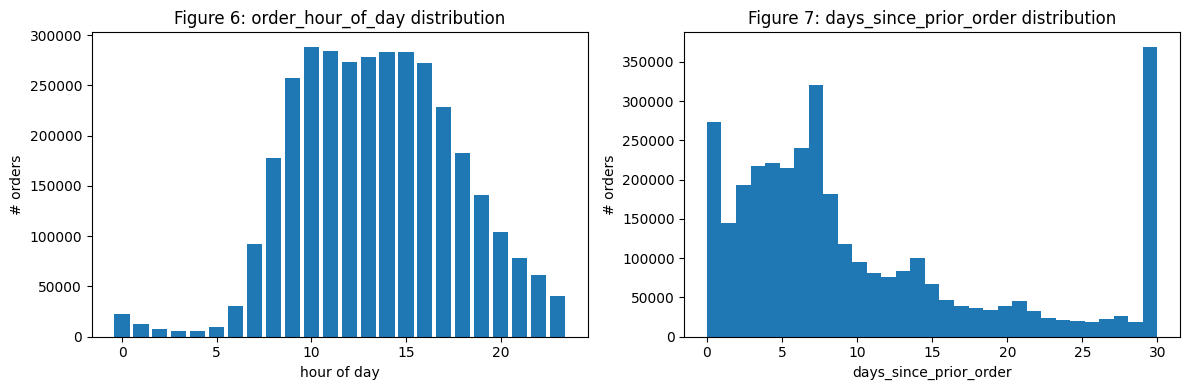


Figure 6: Temporal behavior summary
  order_hour_of_day top 5 hours:
order_hour_of_day
10    288418
11    284728
15    283639
14    283042
13    277999
  days_since_prior_order quantiles: {0.5: 7.0, 0.9: 30.0, 0.99: 30.0}


In [81]:
# Use orders_f to show when users place orders and how long they wait between orders.
orders_time = orders_f.copy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
hour_counts = orders_time["order_hour_of_day"].value_counts().sort_index()
plt.bar(hour_counts.index.astype(int), hour_counts.values)
plt.title("Figure 6: order_hour_of_day distribution")
plt.xlabel("hour of day")
plt.ylabel("# orders")

plt.subplot(1, 2, 2)
plt.hist(orders_time["days_since_prior_order"].values, bins=31)
plt.title("Figure 7: days_since_prior_order distribution")
plt.xlabel("days_since_prior_order")
plt.ylabel("# orders")

plt.tight_layout()
plt.show()

print("\nFigure 6: Temporal behavior summary")
print("  order_hour_of_day top 5 hours:")
print(hour_counts.sort_values(ascending=False).head(5).to_string())
print("  days_since_prior_order quantiles:", orders_time["days_since_prior_order"].quantile([0.5, 0.9, 0.99]).to_dict())


### Figure 8&9: Product-level distribution
These two figures show the distribution of product purchase counts and reorder rates.
- Product purchase counts exhibit an extremely strong long-tail pattern: a small number of products are highly popular, while the majority belong to the long tail
- The median purchase count is only 61, whereas the p99 exceeds 10,000, indicating a highly imbalanced distribution
- Reorder rates vary widely (approximately 0.3–0.7), showing substantial differences across products

There is a clear “head + long tail” structure in product popularity, along with significant heterogeneity in reorder behavior. Both are important features for modeling.


Figure 7: Product-level summary
  p_total_purchases quantiles: {0.5: 61.0, 0.9: 1027.0, 0.99: 10014.800000000105}
  p_reorder_ratio quantiles: {0.5: 0.38095238095238093, 0.9: 0.6363636363636364, 0.99: 0.7758388681648624}


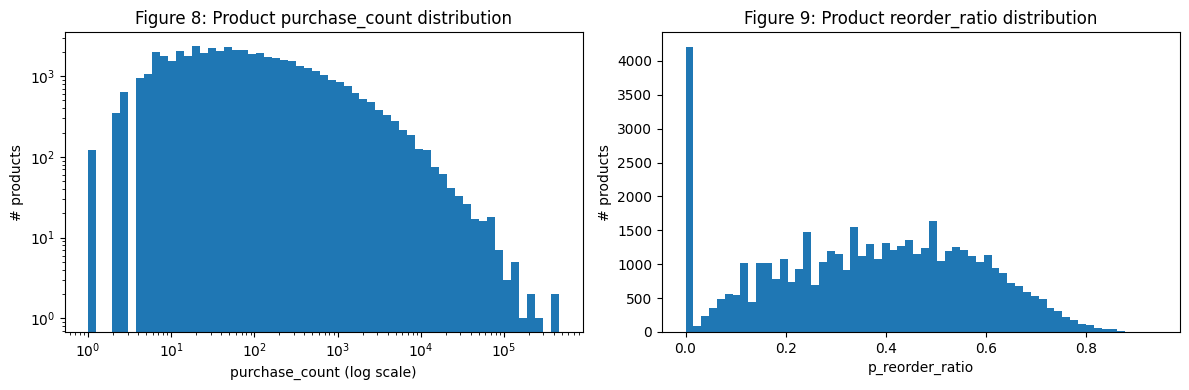

In [93]:
# -----------------------------
# Product-level summary
# -----------------------------
p_total_purchases = history_op.groupby("product_id")["order_id"].size().astype(float)
p_reorder_ratio = history_op.groupby("product_id")["reordered"].mean().astype(float)

print("\nFigure 7: Product-level summary")
print("  p_total_purchases quantiles:", p_total_purchases.quantile([0.5, 0.9, 0.99]).to_dict())
print("  p_reorder_ratio quantiles:", p_reorder_ratio.quantile([0.5, 0.9, 0.99]).to_dict())

plt.figure(figsize=(12, 4))

# Figure 8: product purchase_count distribution
plt.subplot(1, 2, 1)
purchase_bins = np.logspace(
    np.log10(max(1, p_total_purchases.min())),
    np.log10(p_total_purchases.max()),
    60
)
plt.hist(p_total_purchases.values, bins=purchase_bins)
plt.xscale("log")
plt.yscale("log")
plt.title("Figure 8: Product purchase_count distribution")
plt.xlabel("purchase_count (log scale)")
plt.ylabel("# products")

# Figure 9: product reorder_ratio distribution
plt.subplot(1, 2, 2)
plt.hist(p_reorder_ratio.values, bins=60)
plt.title("Figure 9: Product reorder_ratio distribution")
plt.xlabel("p_reorder_ratio")
plt.ylabel("# products")

plt.tight_layout()
plt.show()


### Figure 10 & 11: Department-level behavior
The dataset contains 20 departments, which are ranked by total purchase volume. These two figures show the overall purchase distribution and reorder rates across departments.
- Purchases are highly concentrated: head departments such as produce and dairy eggs significantly outperform others, showing a clear head effect
- Reorder rates are relatively high overall (approximately 0.34–0.65), indicating strong repeat purchasing behavior at the category level
- Departments with high purchase volume also tend to have high reorder rates (e.g., fresh produce and dairy products, which are daily necessities)

There is a stable consumption structure at the department level, which can be used to capture users’ category preferences.


Department summary table
 department_id      department  purchase_count  unique_users  reorder_ratio
             4         produce         9251175        192360       0.649857
            16      dairy eggs         5291410        189418       0.670066
            19          snacks         2819833        172124       0.574233
             7       beverages         2625862        170792       0.653532
             1          frozen         2179561        161061       0.541749
            13          pantry         1829541        170410       0.346843
             3          bakery         1149448        138452       0.628229
            15    canned goods         1040700        131466       0.457324
            20            deli         1026198        131633       0.607681
             9 dry goods pasta          844412        122655       0.460738
            17       household          718699        109507       0.402220
            14       breakfast          692732        111981  

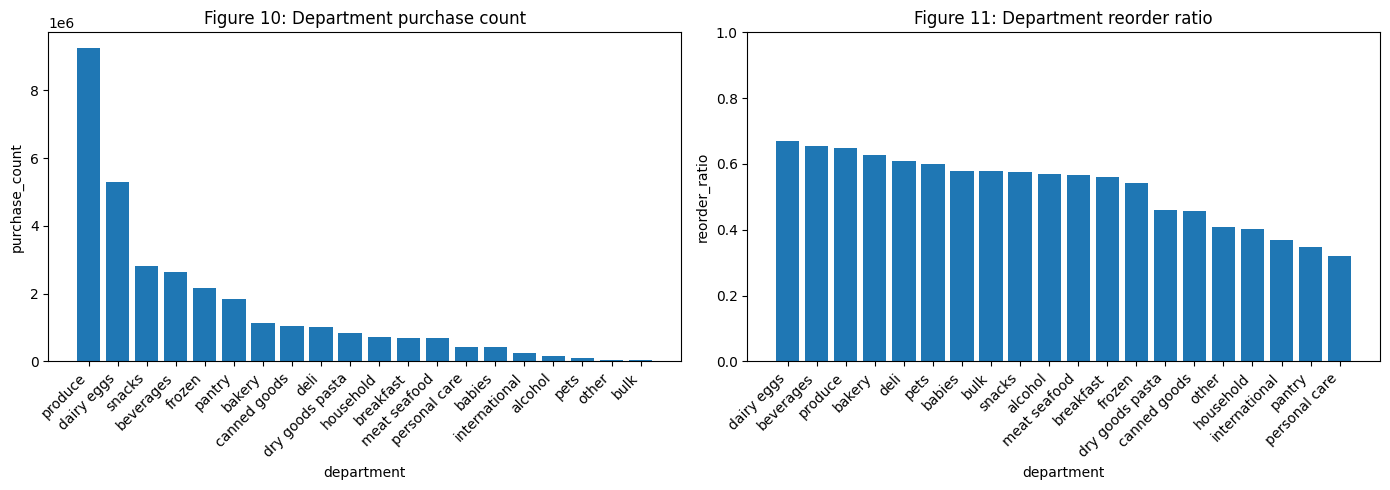

In [90]:
# 10. Department-level analysis
hist_meta = history_op.copy()

# Aggregate summary at the department level
dep_summary = hist_meta.groupby(["department_id", "department"]).agg(
    purchase_count=("order_id", "size"),
    unique_users=("user_id", "nunique"),
    reorder_ratio=("reordered", "mean"),
).reset_index()

dep_summary = dep_summary.sort_values("purchase_count", ascending=False)

print("\nDepartment summary table")
print(dep_summary.to_string(index=False))

# Plot: more interpretable department-level bar charts
plt.figure(figsize=(14, 5))

# Figure 10: purchase_count by department
plt.subplot(1, 2, 1)
dep_pc = dep_summary.sort_values("purchase_count", ascending=False)
plt.bar(dep_pc["department"], dep_pc["purchase_count"])
plt.title("Figure 10: Department purchase count")
plt.xlabel("department")
plt.ylabel("purchase_count")
plt.xticks(rotation=45, ha="right")

# Figure 11: reorder_ratio by department
plt.subplot(1, 2, 2)
dep_rr = dep_summary.sort_values("reorder_ratio", ascending=False)
plt.bar(dep_rr["department"], dep_rr["reorder_ratio"])
plt.title("Figure 11: Department reorder ratio")
plt.xlabel("department")
plt.ylabel("reorder_ratio")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Figure 12 & 13: Aisle-level behavior
The dataset contains 134 aisles, which are ranked by purchase volume and reorder rate, respectively. These two figures show the sales of the top 20 aisles and the reorder rates across different aisles.
- Top-selling aisles are highly concentrated in food categories (e.g., fresh fruits, fresh vegetables, yogurt), reflecting core consumption items
- Some aisles exhibit very high reorder rates (e.g., milk, water), indicating strong necessity-driven demand
- Compared to departments, aisles provide a finer level of granularity, with more pronounced differences across categories
- Reorder rates vary widely (approximately 0.2–0.8), suggesting substantial heterogeneity in “stickiness” across aisles

The aisle level provides more granular behavioral signals and is more suitable than department and product levels as a basis for subsequent product analysis.


Top 15 aisles by purchase_count
 aisle_id                         aisle  purchase_count  unique_users  reorder_ratio
       24                  fresh fruits         3557913        175505       0.717928
       83              fresh vegetables         3334147        157589       0.594550
      123    packaged vegetables fruits         1721841        157200       0.638393
      120                        yogurt         1420886        122489       0.686725
       21               packaged cheese          956306        130789       0.585292
       84                          milk          872160        107494       0.781404
      115 water seltzer sparkling water          821332         97986       0.729461
      107                chips pretzels          704564        109816       0.588808
       91               soy lactosefree          623615         94671       0.692533
      112                         bread          571548        101697       0.670199
       31                  refri

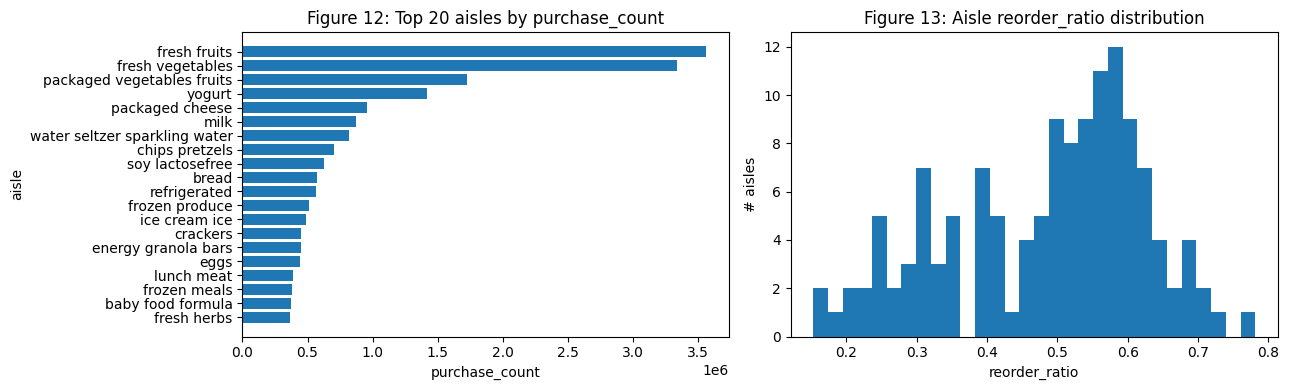

In [92]:
# -----------------------------
# Aisle-level summary
# -----------------------------
aisle_summary = hist_meta.groupby(["aisle_id", "aisle"]).agg(
    purchase_count=("order_id", "size"),
    unique_users=("user_id", "nunique"),
    reorder_ratio=("reordered", "mean"),
).reset_index()

aisle_summary = aisle_summary.sort_values("purchase_count", ascending=False)

print("\nTop 15 aisles by purchase_count")
print(aisle_summary.head(15).to_string(index=False))

MIN_CNT = 1000
print(f"\nTop 15 aisles by reorder_ratio (purchase_count >= {MIN_CNT})")
print(
    aisle_summary[aisle_summary["purchase_count"] >= MIN_CNT]
    .sort_values("reorder_ratio", ascending=False)
    .head(15)
    .to_string(index=False)
)

plt.figure(figsize=(13, 4))

# Figure 12: top aisles by purchase_count
plt.subplot(1, 2, 1)
top_n = 20
aisle_top = aisle_summary.head(top_n).sort_values("purchase_count", ascending=True)
plt.barh(aisle_top["aisle"], aisle_top["purchase_count"])
plt.title(f"Figure 12: Top {top_n} aisles by purchase_count")
plt.xlabel("purchase_count")
plt.ylabel("aisle")

# Figure 13: aisle reorder_ratio distribution
plt.subplot(1, 2, 2)
plt.hist(aisle_summary["reorder_ratio"].values.astype(float), bins=30)
plt.title("Figure 13: Aisle reorder_ratio distribution")
plt.xlabel("reorder_ratio")
plt.ylabel("# aisles")

plt.tight_layout()
plt.show()

## =============================
# User and Product Analysis
## =============================

## User Analysis: Understanding Shopping Style Heterogeneity

The purpose of the user analysis is to understand the heterogeneity in users’ shopping behaviors and identify distinct shopping styles.

---

### Feature Design

We construct five historically-based behavioral features for each user:

- **u_hist_orders**: total number of historical orders  
- **u_mean_days_between_orders**: average days between orders  
- **u_mean_basket_size**: average basket size  
- **u_reorder_rate**: reorder rate  
- **u_unique_products**: number of unique products purchased  

These features correspond to key dimensions of user behavior:

- Activity level  
- Purchase rhythm  
- Per-order purchase scale  
- Loyalty (reordering tendency)  
- Exploration breadth  

We initially experimented with a larger feature set, but reduced it to these five in order to ensure interpretability and usefulness for downstream modeling.

---

### Clustering Method: K-Means

We apply **K-Means clustering** to segment users based on the selected behavioral features.

The objective of K-Means is to minimize the within-cluster variance:

$$
\underset{C_1, \dots, C_K}{\text{minimize}} \;\;
\sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

where:

- \( C_k \) is the set of points assigned to cluster \( k \)  
- \( \mu_k \) is the centroid (mean vector) of cluster \( k \)  
- \( x_i \) is the feature vector of user \( i \)  

This objective encourages users within the same cluster to have similar behavioral patterns by minimizing their distance to the cluster centroid.

---

### Choosing the Number of Clusters (K)

To determine the optimal number of clusters, we use the **Elbow Method**, which examines how the clustering objective (inertia) changes as \( K \) varies.

Inertia is defined as:

$$
\text{Inertia}(K) = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

As \( K \) increases, inertia decreases, but with diminishing marginal improvement.

- We evaluated multiple values of \( K \)
- Selected **K = 4** based on:
  - Clear separation between clusters  
  - Strong interpretability  

Although larger values of \( K \) further reduce inertia, they lead to less distinct and harder-to-interpret clusters.

---

### Clustering Results: User Segments

We obtain four distinct user groups:

1. **Low-reorder, light-exploration users**
   - Low activity and low reorder rate  
   - Limited purchasing behavior  
   - Represent low-commitment users  

2. **Small-basket, routine replenishment users**
   - Small basket size  
   - Stable and concentrated purchases  
   - Likely to restock a fixed set of items  

3. **High-activity, high-reorder users (core users)**
   - High order frequency and strong loyalty  
   - Represent high-value users  

4. **Large-basket, high-breadth stock-up users**
   - Larger baskets and diverse products  
   - Less frequent but high-volume purchases  
   - Mission-driven or bulk buyers  

---

### Implications for Modeling

The clustering results can be used in multiple ways:

- **Feature Engineering**
  - Use cluster labels as user-level features  

- **Model Evaluation**
  - Analyze performance across different user segments  

- **Cold-start / Sparse Users**
  - Leverage behavior of similar users within the same cluster  

---

This clustering approach provides an interpretable and structured way to model user heterogeneity, enabling more personalized and effective recommendation strategies. These cluster labels may be encoded as categorical features and incorporated into the prediction model.

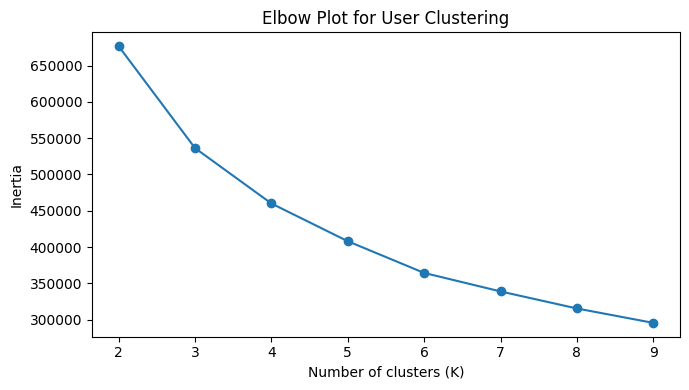

In [86]:
# User clustering based on history behavior
history_users = history_op[history_op["user_id"].isin(eligible_users)].copy()

 # `op_all` built in the EDA section does not carry temporal order metadata,
 # so we re-attach the needed order-level fields from `orders` here.
hist_orders = (
    history_users[["user_id", "order_id", "order_number"]]
    .drop_duplicates(subset=["order_id"])
    .merge(
        orders[["order_id", "order_dow", "order_hour_of_day", "days_since_prior_order"]],
        on="order_id",
        how="left",
    )
    .copy()
)

hist_order_size = (
    history_users.groupby(["user_id", "order_id"])["product_id"]
    .size()
    .rename("basket_size")
    .reset_index()
)

# User-level features for interpretable clustering
u_hist_orders = hist_orders.groupby("user_id")["order_id"].nunique().rename("u_hist_orders")
u_mean_days = hist_orders.groupby("user_id")["days_since_prior_order"].mean().rename("u_mean_days_between_orders")
u_mean_basket = hist_order_size.groupby("user_id")["basket_size"].mean().rename("u_mean_basket_size")
u_reorder_rate = history_users.groupby("user_id")["reordered"].mean().rename("u_reorder_rate")
u_unique_products = history_users.groupby("user_id")["product_id"].nunique().rename("u_unique_products")

user_cluster_features = pd.concat([
    u_hist_orders,
    u_mean_days,
    u_mean_basket,
    u_reorder_rate,
    u_unique_products,
], axis=1).reset_index()

user_cluster_features_raw = user_cluster_features.copy()

cluster_feature_cols = [
    "u_hist_orders",
    "u_mean_days_between_orders",
    "u_mean_basket_size",
    "u_reorder_rate",
    "u_unique_products",
]

# Light transformation for long-tail variables before scaling
for col in ["u_hist_orders", "u_mean_basket_size", "u_unique_products"]:
    user_cluster_features[col] = np.log1p(user_cluster_features[col])

X_user = user_cluster_features[cluster_feature_cols].fillna(0).copy()
scaler = StandardScaler()
X_user_scaled = scaler.fit_transform(X_user)

# Elbow method
k_values = list(range(2, 10))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_user_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Plot for User Clustering")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [87]:
# 6.1 KMeans user clustering with 5 interpretable features (K=4)
kmeans_user = KMeans(n_clusters=4, random_state=420, n_init=20)
user_cluster_features["user_cluster"] = kmeans_user.fit_predict(X_user_scaled)

cluster_sizes = (
    user_cluster_features["user_cluster"]
    .value_counts()
    .sort_index()
    .rename("n_users")
    .reset_index()
    .rename(columns={"index": "user_cluster"})
)

user_cluster_features_raw["user_cluster"] = user_cluster_features["user_cluster"].values

cluster_profile_raw_cols = [
    "u_hist_orders",
    "u_mean_days_between_orders",
    "u_mean_basket_size",
    "u_reorder_rate",
    "u_unique_products",
]

cluster_profile_raw = (
    user_cluster_features_raw.groupby("user_cluster")[cluster_profile_raw_cols]
    .mean()
    .reset_index()
)

print("\nUser cluster sizes (5-feature KMeans, K=4):")
print("K candidates checked:", k_values)
print("Inertias:", [round(x, 2) for x in inertias])
print(cluster_sizes.to_string(index=False))

print("\nUser cluster profile on RAW scale (5 clustering features):")
print(cluster_profile_raw.to_string(index=False))

print(
    "\nCluster interpretation:\n"
    "Cluster 0： low reorder, light exploration users\n"
    "Cluster 1：small basket, low variety, routine refill users\n"
    "Cluster 2：high activity, high reorder, core heavy users\n"
    "Cluster 3：large basket, high variety, stock-up users"
)


User cluster sizes (5-feature KMeans, K=4):
K candidates checked: [2, 3, 4, 5, 6, 7, 8, 9]
Inertias: [676620.25, 536309.18, 460067.77, 408115.07, 364480.26, 339007.91, 315547.7, 295699.93]
 user_cluster  n_users
            0    64733
            1    61661
            2    42224
            3    37591

User cluster profile on RAW scale (5 clustering features):
 user_cluster  u_hist_orders  u_mean_days_between_orders  u_mean_basket_size  u_reorder_rate  u_unique_products
            0      32.779309                    8.761034           11.120919        0.627606         113.421887
            1       8.410405                   17.135110           12.681294        0.357215          60.751772
            2       4.693066                    8.947882            9.710516        0.223303          31.553406
            3       8.006943                   15.342642            3.524225        0.402890          13.958288

Cluster interpretation:
Cluster 0： low reorder, light exploration users
Cl

## Basket-level Association Analysis (Apriori)

In the previous analysis, we conducted preliminary product-level exploration, including sales distributions at the aisle and department levels.

Building on this, we move to **basket-level association analysis** using the Apriori method. The goal is to identify which aisles are frequently purchased together within the same order.

Compared to product-level analysis, we choose to operate at the **aisle level** for two main reasons:

- Reduce sparsity (products are too numerous, leading to sparse combinations)  
- Improve interpretability (closer to real consumption scenarios)  

---

### Data Processing and Method

The procedure is as follows:

1. Convert each order into an **aisle basket**
   - One order → one set of aisles  

2. Based on all orders, compute:
   - Frequency of individual aisles  
   - Co-occurrence frequency of aisle pairs  

We then calculate three standard association rule metrics:

#### Support

$$
\text{support}(A, B) = \frac{\#(A, B)}{\#(\text{all orders})}
$$

This measures how frequently a combination appears across all orders.

---

#### Confidence

$$
\text{confidence}(A \rightarrow B) = P(B \mid A) = \frac{\text{support}(A, B)}{\text{support}(A)}
$$

This measures the probability of observing B given that A is present.

---

#### Lift

$$
\text{lift}(A, B) = \frac{P(A, B)}{P(A)\,P(B)}
$$

This measures whether the co-occurrence is stronger than random expectation:

- lift > 1: positive association  
- lift = 1: independent  
- lift < 1: negative association  

---

### Threshold Selection

We apply the following thresholds:

- support ≥ 0.01  
- confidence ≥ 0.30  
- lift ≥ 1.30  

These values are chosen empirically based on the dataset scale and distribution, aiming to balance **rule quality** and **coverage**:

- **support ≥ 0.01**
  - Corresponds to at least ~2,000 occurrences in ~200K orders  
  - Filters out low-frequency and noisy combinations  

- **confidence ≥ 0.30**
  - Ensures that given A, B appears with at least 30% probability  
  - Removes weak and less informative associations  

- **lift ≥ 1.30**
  - Requires the co-occurrence to be at least 30% stronger than random expectation  
  - Filters out spurious correlations caused by popular items  

Together, these thresholds control:

- Frequency (support)  
- Strength (confidence)  
- Non-randomness (lift)  

After filtering and deduplication, we obtain **138 aisle-level association pairs**.

---

### Pattern Interpretation

The resulting rules reveal clear consumption patterns:

- **Meal-based combinations**  
- **Snack-oriented purchasing patterns**  
- **Cooking-related pairings**  

These patterns reflect meaningful user behavior rather than random co-occurrence.

---

### Network Structure Analysis

To better understand these relationships, we visualize them as a network graph:

- **Nodes**: aisles  
- **Edges**: strong co-purchase relationships  

Interpretation:

- Larger nodes → aisles connected to more other aisles (hub categories)  
- Thicker edges → stronger associations  

This shifts the analysis from individual rules to a **network perspective**, helping identify core categories and key connections in the shopping ecosystem.

---

### Implications for Recommendation

These association rules can be used for **candidate expansion** in recommendation systems.

If candidates are generated only from a user’s historical purchases:

$$
\mathcal{C}_{\text{history}}(u)
$$

the model mainly captures **reorder behavior** and tends to be conservative.

With association rules, the candidate set can be expanded as:

$$
\mathcal{C}_{\text{expanded}}(u)
=
\mathcal{C}_{\text{history}}(u)
\cup
\{ j : \exists i \in \mathcal{C}_{\text{history}}(u), (i,j)\in\mathcal{R} \}
$$

This allows us to:

- Introduce items from strongly associated aisles  
- Enable cross-category recommendations  
- Increase diversity beyond historical purchases  

---

### Summary

This analysis extends from user behavior to **product relationships**:

- Captures co-purchase structure across categories  
- Identifies interpretable consumption patterns  
- Enhances recommendation systems through cross-category expansion  

As a result, the model evolves from purely learning **reorder behavior** to recommending **related new items**.

I provided additional empirical support for the previously introduced user segmentation (KMeans) and association analysis (Apriori).
Previously, I mentioned that at the user level, I selected five core features, corresponding to activity level, purchase rhythm, basket size, loyalty,
and exploration breadth.
Here, I further support the necessity of these features with data and explain why clustering is appropriate, why KMeans is chosen, and
why we set K=4.
From the correlation analysis, although these five features are somewhat correlated, they are not redundant. Each captures a distinct behavioral
dimension, making them suitable for characterizing user shopping styles.
I then conducted PCA analysis, where the first two principal components explain approximately 76.5% of the total variance. This indicates that user behavior is not randomly distributed, but rather driven by a small number of latent factors. In other words, the data exhibits a clear low-dimensional structure, which supports the use of clustering.
For clustering, I applied KMeans and evaluated K from 2 to 9. The inertia consistently decreases without a clear elbow point. Meanwhile, the
silhouette score is highest at K=2(0.30) and gradually declines as K increases. This suggests that the data distribution is more continuous rather than forming clearly separated clusters.
Therefore, the final choice of K= 4 is a trade-off between statistical separation and business interpretability.

 Regarding why DBSCAN was not used:
First, given the large dataset, KMeans has a clear advantage in computational efficiency.
Second, in a sampled experiment, DBSCAN identified only three clusters, where one cluster dominated the majority of data points, while the other
two were extremely small. Additionally, about 23% of the data points were classified as noise. This indicates that under this low-dimensional, continuous feature space, DBSCAN produces highly imbalanced and less useful clustering results.
Overall, for large-scale, low-dimensional, and continuous behavioral data, KMeans is more stable and more suitable for interpretable
user segmentation.
As mentioned earlier, the resulting four clusters also have clear business interpretations: core heavy users, exploratory users, light users, and replenishment-focused users. These segments provide a solid foundation for downstream strategy analysis.

In [95]:
# 7. Basket-level association analysis for bundling opportunities
# Goal:
# Identify co-purchase patterns that can support bundling, cross-sell,
# and category-operation discussions.

basket_aisles = (
    op_all.groupby("order_id")["aisle"]
    .apply(lambda x: sorted(set(x.dropna().astype(str))))
    .reset_index(name="aisle_basket")
)

basket_aisles = basket_aisles[basket_aisles["aisle_basket"].str.len() >= 2].copy()
n_baskets = len(basket_aisles)

single_counts = {}
pair_counts = {}

for basket in basket_aisles["aisle_basket"]:
    for item in basket:
        single_counts[item] = single_counts.get(item, 0) + 1

    for i in range(len(basket)):
        for j in range(i + 1, len(basket)):
            pair = (basket[i], basket[j])
            pair_counts[pair] = pair_counts.get(pair, 0) + 1


def build_aisle_rules(single_counts, pair_counts, n_baskets, min_support, min_confidence, min_lift):
    rule_rows_local = []
    for (a, b), pair_cnt in pair_counts.items():
        support = pair_cnt / n_baskets
        conf_a_to_b = pair_cnt / single_counts[a]
        conf_b_to_a = pair_cnt / single_counts[b]
        lift_a_to_b = conf_a_to_b / (single_counts[b] / n_baskets)
        lift_b_to_a = conf_b_to_a / (single_counts[a] / n_baskets)

        rule_rows_local.append({
            "antecedent": a,
            "consequent": b,
            "pair_count": pair_cnt,
            "support": support,
            "confidence": conf_a_to_b,
            "lift": lift_a_to_b,
        })
        rule_rows_local.append({
            "antecedent": b,
            "consequent": a,
            "pair_count": pair_cnt,
            "support": support,
            "confidence": conf_b_to_a,
            "lift": lift_b_to_a,
        })

    rules_local = pd.DataFrame(rule_rows_local)
    if rules_local.empty:
        return rules_local, 0

    rules_local = rules_local[
        (rules_local["support"] >= min_support) &
        (rules_local["confidence"] >= min_confidence) &
        (rules_local["lift"] >= min_lift)
    ].copy()

    if rules_local.empty:
        return rules_local, 0

    rules_local = rules_local.sort_values(
        ["lift", "confidence", "pair_count"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    rules_local["pair_key"] = rules_local.apply(
        lambda row: tuple(sorted([row["antecedent"], row["consequent"]])),
        axis=1,
    )

    unique_pairs_local = int(rules_local["pair_key"].nunique())
    return rules_local, unique_pairs_local



# Thresholds for actionable bundling relations
min_support = 0.01
min_confidence = 0.30
min_lift = 1.30

rules_filtered, unique_rule_pairs_count = build_aisle_rules(
    single_counts=single_counts,
    pair_counts=pair_counts,
    n_baskets=n_baskets,
    min_support=min_support,
    min_confidence=min_confidence,
    min_lift=min_lift,
)

if len(rules_filtered) > 0:
    rules_unique_pairs = (
        rules_filtered.sort_values(
            ["lift", "confidence", "pair_count"],
            ascending=[False, False, False]
        )
        .drop_duplicates(subset=["pair_key"])
        .reset_index(drop=True)
    )
else:
    rules_unique_pairs = pd.DataFrame(
        columns=["antecedent", "consequent", "pair_count", "support", "confidence", "lift", "pair_key"]
    )

rules_top = rules_unique_pairs.head(15).copy()

print("\nUnique deduplicated bundling pairs after filtering:", unique_rule_pairs_count)
print("\nTop aisle-level association rules for bundling opportunities:")
if len(rules_top) == 0:
    print("No aisle-level rules passed the current support/confidence/lift thresholds.")
else:
    print(rules_top.drop(columns=["pair_key"]).to_string(index=False))




Unique deduplicated bundling pairs after filtering: 137

Top aisle-level association rules for bundling opportunities:
            antecedent       consequent  pair_count  support  confidence     lift
           pasta sauce        dry pasta       65410 0.020860    0.314931 4.180565
preserved dips spreads   chips pretzels       45898 0.014637    0.430220 2.416904
  fresh dips tapenades   chips pretzels      117708 0.037538    0.359870 2.021689
               granola           yogurt       51217 0.016333    0.548808 1.967582
         cookies cakes   chips pretzels       68121 0.021724    0.347273 1.950920
         popcorn jerky   chips pretzels       51668 0.016477    0.343045 1.927168
fruit vegetable snacks   chips pretzels       52413 0.016715    0.342045 1.921555
            lunch meat            bread      113505 0.036197    0.326938 1.876924
tofu meat alternatives  soy lactosefree       37055 0.011817    0.337459 1.875500
           pasta sauce  packaged cheese       91691 0.029241

### Threshold Selection (Based on Sensitivity Analysis)

To systematically select the three Apriori thresholds (support, confidence, and lift), we performed a grid search over different parameter combinations and analyzed their impact through visualization.

---

### 1. Sensitivity Analysis (Figure: Heatmap)

For different lift thresholds (1.2 / 1.3 / 1.4), we visualize the number of retained rules (# unique aisle pairs) under varying support and confidence levels.

We observe the following patterns:

- As **support increases** or **confidence becomes stricter**, the number of rules decreases significantly  
- Increasing the **lift threshold** further reduces the total number of rules  

More specifically:

- Under low thresholds (e.g., support = 0.005, confidence = 0.2):
  - A large number of rules are generated (>400), but many are noisy  

- Under high thresholds (e.g., support = 0.02, confidence = 0.4):
  - The number of rules drops sharply (<50), leading to insufficient coverage  

- Around **support ≈ 0.01 and confidence ≈ 0.30**:
  - The number of rules falls into a moderate range (approximately 100–200), indicating a more balanced setting  

---

### 2. Trade-off Analysis (Figure: Scatter)

We further map each parameter combination into a trade-off space:

- x-axis: number of rules (# unique aisle pairs)  
- y-axis: rule quality (median lift)  
- point size: number of rules (for visual emphasis)  
- color: lift threshold  

A clear trade-off emerges:

- More rules → lower median lift (weaker associations)  
- Fewer rules → higher median lift (stronger but sparse associations)  

The selected parameter combination (marked as *chosen*) lies in:

- A moderate rule count (approximately 130–160 rules)  
- Relatively high rule quality (median lift ≈ 1.4+)  

This position corresponds to:

👉 **A balanced region between rule quantity and rule strength**

---

### 3. Final Selection

Based on the above analysis, we choose:

- **support ≥ 0.01**
- **confidence ≥ 0.30**
- **lift ≥ 1.30**

This choice is justified because:

- In the heatmap, it lies within a stable region with neither too many nor too few rules  
- In the trade-off plot, it achieves a good balance between rule quality and coverage  
- It yields approximately 138 rules, which are both interpretable and robust  

---

### 4. Summary

These thresholds are not theoretically determined, but are selected based on:

- Sensitivity analysis (heatmap)  
- Quality–quantity trade-off (scatter plot)  

In essence, the selection balances:

- Coverage (rule count)  
- Strength (lift / confidence)  
- Stability (support)  

resulting in a set of association rules that are both reliable and practically meaningful.

I provided empirical justification for using the aisle level instead of the product level.
At the product level, the pairwise combination space is approximately 373 per basket, while at the aisle level, it is only about 0.0028. This implies that product-level combinations are extremely sparse and unstable, whereas aisle-level combinations are more concentrated and more likely to produce stable and interpretable patterns.
Therefore, the goal of association analysis is not to identify the most fine-grained combinations, but to extract stable patterns that can support cross-selling and bundling strategies. From this perspective, the aisle level is more appropriate.


Apriori threshold sensitivity summary (first 10 rows):
 support  confidence  lift  n_rules  n_unique_pairs  median_rule_lift  median_rule_confidence  covered_aisles
   0.005        0.20   1.1      693             654          1.309245                0.312412              89
   0.005        0.25   1.1      476             459          1.297200                0.363980              89
   0.005        0.30   1.1      369             358          1.275417                0.433282              81
   0.005        0.35   1.1      262             257          1.281253                0.513985              74
   0.005        0.40   1.1      200             197          1.242286                0.557427              72
   0.010        0.20   1.1      533             494          1.291973                0.331798              77
   0.010        0.25   1.1      389             372          1.294307                0.381070              77
   0.010        0.30   1.1      315             304          1.2

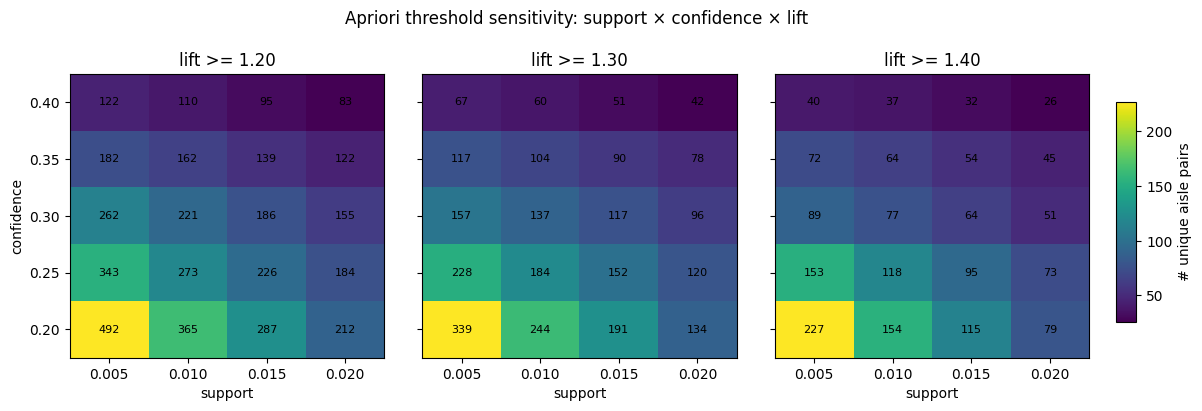

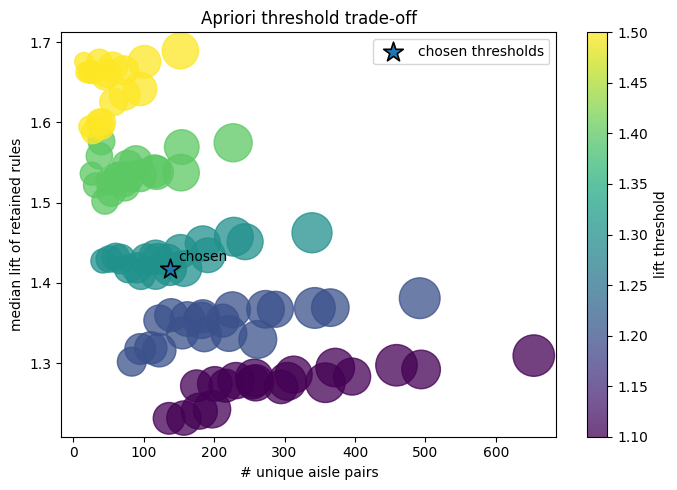

In [98]:
## =====================================================
# 7.0 Threshold sensitivity analysis for Apriori rules
## =====================================================
support_grid = [0.005, 0.01, 0.015, 0.02]
confidence_grid = [0.20, 0.25, 0.30, 0.35, 0.40]
lift_grid_all = [1.10, 1.20, 1.30, 1.40, 1.50]
lift_grid_heatmap = [1.20, 1.30, 1.40]

grid_rows = []
for cur_lift in lift_grid_all:
    for cur_support in support_grid:
        for cur_confidence in confidence_grid:
            rules_tmp, unique_pairs_tmp = build_aisle_rules(
                single_counts=single_counts,
                pair_counts=pair_counts,
                n_baskets=n_baskets,
                min_support=cur_support,
                min_confidence=cur_confidence,
                min_lift=cur_lift,
            )

            if len(rules_tmp) > 0:
                median_lift_tmp = float(rules_tmp["lift"].median())
                median_conf_tmp = float(rules_tmp["confidence"].median())
                covered_aisles_tmp = int(pd.unique(
                    pd.concat([
                        rules_tmp["antecedent"],
                        rules_tmp["consequent"],
                    ], ignore_index=True)
                ).shape[0])
            else:
                median_lift_tmp = np.nan
                median_conf_tmp = np.nan
                covered_aisles_tmp = 0

            grid_rows.append({
                "support": cur_support,
                "confidence": cur_confidence,
                "lift": cur_lift,
                "n_rules": int(len(rules_tmp)),
                "n_unique_pairs": int(unique_pairs_tmp),
                "median_rule_lift": median_lift_tmp,
                "median_rule_confidence": median_conf_tmp,
                "covered_aisles": covered_aisles_tmp,
            })

grid_df = pd.DataFrame(grid_rows)

print("\nApriori threshold sensitivity summary (first 10 rows):")
print(grid_df.head(10).to_string(index=False))

# Heatmaps: for each lift threshold, show number of unique rule pairs
fig, axes = plt.subplots(1, len(lift_grid_heatmap), figsize=(4.5 * len(lift_grid_heatmap), 4), sharey=True)
if len(lift_grid_heatmap) == 1:
    axes = [axes]

for ax, cur_lift in zip(axes, lift_grid_heatmap):
    heat = (
        grid_df[grid_df["lift"] == cur_lift]
        .pivot(index="confidence", columns="support", values="n_unique_pairs")
        .sort_index(ascending=False)
    )

    im = ax.imshow(heat.values, aspect="auto")
    ax.set_title(f"lift >= {cur_lift:.2f}")
    ax.set_xlabel("support")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"{v:.3f}" for v in heat.columns])

    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in heat.index])
    if ax is axes[0]:
        ax.set_ylabel("confidence")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            txt = "NA" if pd.isna(val) else str(int(val))
            ax.text(j, i, txt, ha="center", va="center", fontsize=8)

fig.subplots_adjust(right=0.88, top=0.82, wspace=0.12)
cbar_ax = fig.add_axes([0.90, 0.20, 0.015, 0.55])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("# unique aisle pairs")
fig.suptitle("Apriori threshold sensitivity: support × confidence × lift")
plt.show()

# Trade-off scatter: number of pairs vs median lift, point size = covered aisles
plot_df = grid_df[grid_df["n_unique_pairs"] > 0].copy()
if len(plot_df) > 0:
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        plot_df["n_unique_pairs"],
        plot_df["median_rule_lift"],
        s=plot_df["covered_aisles"] * 10,
        c=plot_df["lift"],
        alpha=0.75,
    )

    chosen_mask = (
        (plot_df["support"] == min_support) &
        (plot_df["confidence"] == min_confidence) &
        (plot_df["lift"] == min_lift)
    )
    chosen_df = plot_df[chosen_mask]
    if len(chosen_df) > 0:
        plt.scatter(
            chosen_df["n_unique_pairs"],
            chosen_df["median_rule_lift"],
            s=220,
            marker="*",
            edgecolors="black",
            linewidths=1.2,
            label="chosen thresholds",
        )
        for _, row in chosen_df.iterrows():
            plt.annotate(
                "chosen",
                (row["n_unique_pairs"], row["median_rule_lift"]),
                xytext=(6, 6),
                textcoords="offset points",
            )

    plt.title("Apriori threshold trade-off")
    plt.xlabel("# unique aisle pairs")
    plt.ylabel("median lift of retained rules")
    plt.legend(loc="best")
    cbar = plt.colorbar(scatter)
    cbar.set_label("lift threshold")
    plt.tight_layout()
    plt.show()

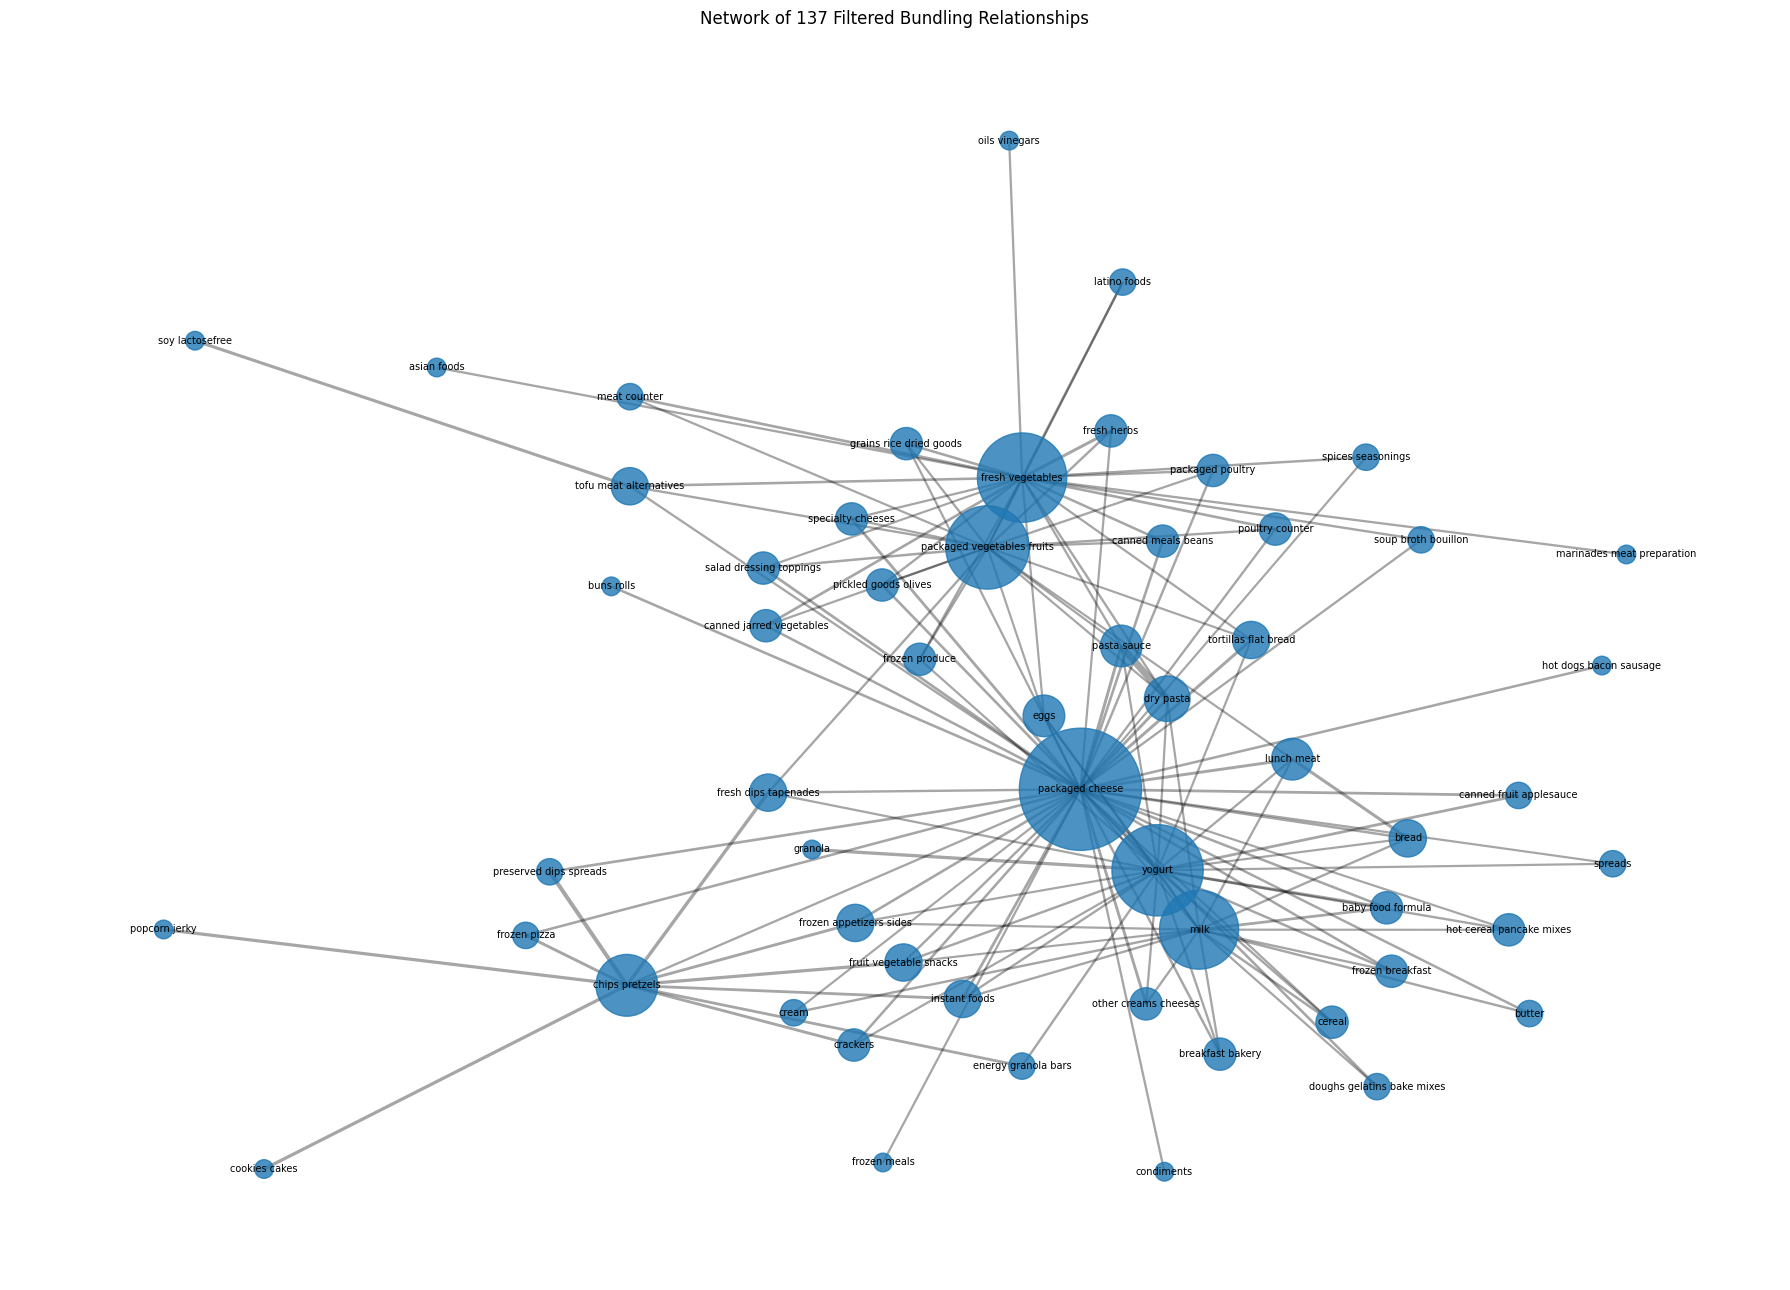

In [97]:
# 7.0A Visualize bundling network
if len(rules_unique_pairs) > 0:
    try:
        import networkx as nx

        rules_plot = rules_unique_pairs.copy()

        G = nx.Graph()
        for _, row in rules_plot.iterrows():
            G.add_edge(
                row["antecedent"],
                row["consequent"],
                weight=row["lift"],
                support=row["support"],
                pair_count=row["pair_count"],
            )

        node_degree = dict(G.degree())
        node_sizes = [node_degree[node] * 180 for node in G.nodes()]
        edge_widths = [G[u][v]["weight"] * 1.2 for u, v in G.edges()]

        plt.figure(figsize=(18, 13))
        pos = nx.spring_layout(G, seed=42, k=1.6, iterations=200)

        nx.draw_networkx_nodes(
            G,
            pos,
            node_size=node_sizes,
            alpha=0.8,
        )
        nx.draw_networkx_edges(
            G,
            pos,
            width=edge_widths,
            alpha=0.35,
        )
        nx.draw_networkx_labels(
            G,
            pos,
            labels={node: node for node in G.nodes()},
            font_size=7,
        )

        plt.title(f"Network of {len(rules_unique_pairs)} Filtered Bundling Relationships")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("networkx is not installed, so the bundling network graph was skipped.")


I constructed five categories of features:
User-level features to describe overall user behavior;
Product-level features to describe product characteristics;
User-product interaction features, which are the most critical;
Temporal features to capture recency;
Collaborative filtering features using ALS embeddings to represent latent similarities.
On top of these, I introduced two types of enhanced features.
The first is KMeans-derived features. In addition to the cluster label, I constructed features such as c/uster_product_ target_rate, which measures the probability that a product appears in the target order within a given user cluster.
The second is Apriori-derived features. The idea is to take the aisles from the user's most recent historical basket and evaluate whether the
candidate product's aisle has strong association rules with them.
For feature selection, I applied a two-step strategy.
First, a weak filter based on univariate AUC was used to remove features with little discriminative power.
Second, I trained a Random Forest model on a sampled dataset and selected the top 20 features based on feature importance, capturing their
contribution in a multivariate setting.
The final selection rule is: a feature is retained if it is either individually useful or important in the model.

=== Recommended final feature list ===

['up_orders_since_last', 'up_days_since_last', 'up_freq', 'up_reorder_ratio', 'up_buy_cnt', 'up_reorder_cnt', 'p_reorder_ratio', 'cluster_product_target_rate', 'u_total_orders', 'p_avg_cart_order', 'u_reorder_ratio', 'u_unique_products', 'p_total_purchases', 'up_first_order', 'p_unique_users', 'u_avg_days_between_orders', 'up_last_order', 'u_total_items', 'u_avg_basket_size', 'up_avg_cart_order', 'user_cluster_0', 'user_cluster', 'apriori_rule_hits']


### Machine Learning Morphism (MLM)

Step 1: Data → Feature Space

We construct features from three levels:
- User-level (activity, reorder rate, basket size)
- Product-level (popularity, reorder ratio)
- User–product interaction (frequency, recency)

Step 2: Candidate Generation
- Baseline: previously purchased products
- Extended: association-rule-based expansion

Step 3: Modeling
- Logistic Regression (baseline)
- LightGBM / CatBoost (main models)

Step 4: Prediction → Ranking
- Predict purchase probability
- Rank products per user
- Select Top-K items

Step 5: Evaluation
- Classification: Precision, Recall, F1
- Ranking: Precision@K, Recall@K, NDCG@K

# githublink
https://github.com/Bettinapb/5971-Team-404-not-found.git

### Next Steps

Week 1:
- Finalize feature engineering (user, product, interaction features)

Week 2:
- Train baseline models (Logistic Regression, LightGBM)
- Evaluate classification performance

Week 3:
- Implement ranking framework (Top-K recommendation)
- Evaluate using Precision@K and Recall@K

Week 4:
- Incorporate association rules for candidate expansion
- Compare performance with/without expansion

Week 5:
- Segment-based evaluation
- Analyze performance across different user clusters

In [8]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

# Optional libraries
try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

try:
    from implicit.als import AlternatingLeastSquares
    from scipy.sparse import coo_matrix
    HAS_IMPLICIT_ALS = True
except Exception:
    HAS_IMPLICIT_ALS = False


# =====================================================
# 1. Read processed feature table
# =====================================================

DATA_PATH = "/Users/bettinabopeng/.cache/kagglehub/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/versions/1/processed_outputs/instacart_feature_table_selected.parquet"

if DATA_PATH.endswith(".parquet"):
    model_df = pd.read_parquet(DATA_PATH)
elif DATA_PATH.endswith(".csv"):
    model_df = pd.read_csv(DATA_PATH)
else:
    raise ValueError("DATA_PATH must be a .csv or .parquet file")


print("\n=== Loaded modeling table ===")
print(model_df.shape)
print(model_df.columns.tolist())


=== Loaded modeling table ===
(12945171, 26)
['user_id', 'product_id', 'label', 'user_cluster', 'up_orders_since_last', 'up_days_since_last', 'up_freq', 'up_buy_cnt', 'up_reorder_cnt', 'up_reorder_ratio', 'p_reorder_ratio', 'u_total_orders', 'cluster_product_target_rate', 'p_avg_cart_order', 'u_reorder_ratio', 'u_unique_products', 'p_total_purchases', 'up_first_order', 'u_avg_days_between_orders', 'p_unique_users', 'up_last_order', 'u_total_items', 'u_avg_basket_size', 'up_avg_cart_order', 'user_cluster_0', 'apriori_rule_hits']



=== Data preview ===
   user_id  product_id  label  user_cluster  up_orders_since_last  up_days_since_last  up_freq  up_buy_cnt  up_reorder_cnt  up_reorder_ratio  p_reorder_ratio  u_total_orders  cluster_product_target_rate  p_avg_cart_order  u_reorder_ratio  u_unique_products  p_total_purchases  up_first_order  u_avg_days_between_orders  p_unique_users  up_last_order  u_total_items  u_avg_basket_size  up_avg_cart_order  user_cluster_0  apriori_rule_hits
0        1         196      1             3                     0                 0.0      1.0          10               9          0.900000         0.776150              10                     0.032401          3.722477         0.694915                 18              34952               1                       17.6            7824             10             59                5.9           1.400000               0                  0
1        1       10258      1             3                     0                 0.0      0.9        

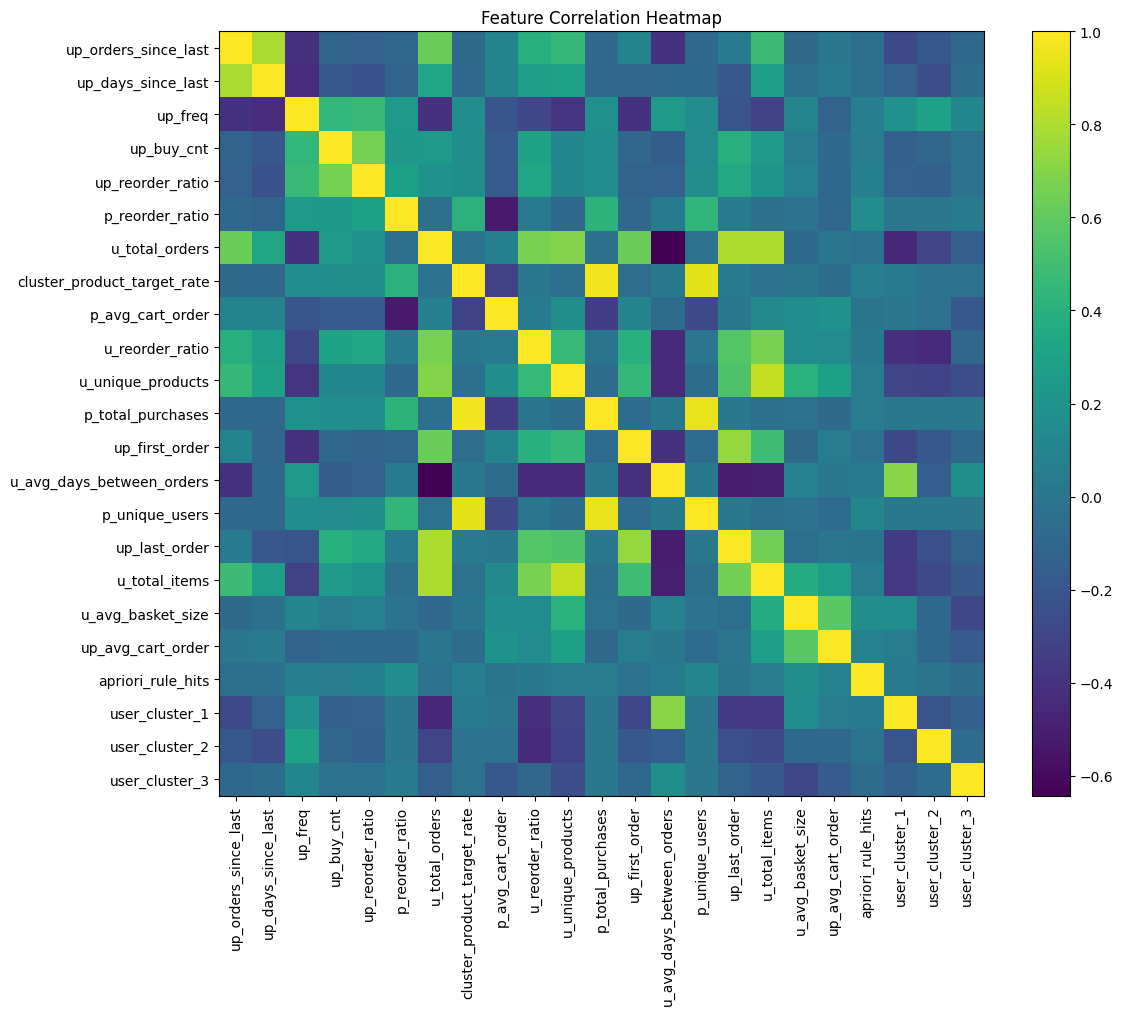

In [9]:
# =====================================================
# 1.1 Basic data inspection and preprocessing
# =====================================================

id_cols = ["user_id", "product_id", "label"]

print("\n=== Data preview ===")
print(model_df.head())

print("\n=== Label distribution ===")
print(model_df["label"].value_counts(dropna=False).sort_index())
print("Positive rate:", float(model_df["label"].mean()))

# Identify categorical columns for dummy encoding.
# Rule:
# 1) object/category/bool columns are categorical
# 2) low-cardinality integer columns (except ids/label) are treated as categorical
# 3) already-dummied binary indicator columns should NOT be dummy-encoded again
raw_feature_cols = [col for col in model_df.columns if col not in id_cols]
object_like_cols = [
    col for col in raw_feature_cols
    if str(model_df[col].dtype) in ["object", "category", "bool"]
]
low_card_int_cols = [
    col for col in raw_feature_cols
    if (pd.api.types.is_integer_dtype(model_df[col]) and model_df[col].nunique(dropna=False) <= 20)
]
already_dummy_binary_cols = [
    col for col in raw_feature_cols
    if col.startswith("user_cluster_") and col != "user_cluster"
]
categorical_feature_cols = sorted(
    set(object_like_cols + low_card_int_cols) - set(already_dummy_binary_cols)
)

print("\n=== Categorical columns selected for dummy encoding ===")
print(categorical_feature_cols)

print("\n=== Already-dummied binary columns kept as-is ===")
print(already_dummy_binary_cols)

# Drop pre-existing cluster dummy columns before re-encoding the raw cluster label.
# This avoids double encoding such as user_cluster_0 -> user_cluster_0_0 / user_cluster_0_1.
cluster_dummy_cols_to_drop = [
    col for col in already_dummy_binary_cols
    if col in model_df.columns
]
if cluster_dummy_cols_to_drop:
    model_df = model_df.drop(columns=cluster_dummy_cols_to_drop)

if categorical_feature_cols:
    model_df = pd.get_dummies(
        model_df,
        columns=categorical_feature_cols,
        drop_first=True,
        dtype=int,
    )

# Fill numeric missing values after encoding.
numeric_fill_cols = [col for col in model_df.columns if col not in id_cols]
model_df[numeric_fill_cols] = model_df[numeric_fill_cols].replace([np.inf, -np.inf], np.nan)
model_df[numeric_fill_cols] = model_df[numeric_fill_cols].fillna(0)

print("\n=== Shape after dummy encoding / filling ===")
print(model_df.shape)

print("\n=== Columns after cluster cleanup and encoding ===")
print(model_df.columns.tolist())

# Correlation analysis on a manageable subset of numeric columns.
feature_cols_after_encoding = [col for col in model_df.columns if col not in id_cols]
corr_candidate_cols = [
    col for col in feature_cols_after_encoding
    if pd.api.types.is_numeric_dtype(model_df[col])
]

# Keep the most variable columns if the feature set is large, to avoid an enormous correlation matrix.
MAX_CORR_COLS = 40
if len(corr_candidate_cols) > MAX_CORR_COLS:
    col_var = model_df[corr_candidate_cols].var().sort_values(ascending=False)
    corr_cols = col_var.head(MAX_CORR_COLS).index.tolist()
else:
    corr_cols = corr_candidate_cols

corr_matrix = model_df[corr_cols].corr()
# Remove one perfectly correlated feature to simplify the feature set.
# up_buy_cnt and up_reorder_cnt are perfectly correlated in the current table,
# so we keep up_buy_cnt and drop up_reorder_cnt.
if "up_buy_cnt" in corr_matrix.columns and "up_reorder_cnt" in corr_matrix.columns:
    if np.isclose(corr_matrix.loc["up_buy_cnt", "up_reorder_cnt"], 1.0):
        model_df = model_df.drop(columns=["up_reorder_cnt"])
        feature_cols_after_encoding = [col for col in model_df.columns if col not in id_cols]
        corr_candidate_cols = [
            col for col in feature_cols_after_encoding
            if pd.api.types.is_numeric_dtype(model_df[col])
        ]
        if len(corr_candidate_cols) > MAX_CORR_COLS:
            col_var = model_df[corr_candidate_cols].var().sort_values(ascending=False)
            corr_cols = col_var.head(MAX_CORR_COLS).index.tolist()
        else:
            corr_cols = corr_candidate_cols
        corr_matrix = model_df[corr_cols].corr()
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)


plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [10]:
# =====================================================
# 2. Define feature columns
# =====================================================

model_feature_cols = [col for col in model_df.columns if col not in id_cols]

print("\n=== Number of model features ===")
print(len(model_feature_cols))
print("\n=== Final feature columns ===")
print(model_feature_cols)



=== Number of model features ===
23

=== Final feature columns ===
['up_orders_since_last', 'up_days_since_last', 'up_freq', 'up_buy_cnt', 'up_reorder_ratio', 'p_reorder_ratio', 'u_total_orders', 'cluster_product_target_rate', 'p_avg_cart_order', 'u_reorder_ratio', 'u_unique_products', 'p_total_purchases', 'up_first_order', 'u_avg_days_between_orders', 'p_unique_users', 'up_last_order', 'u_total_items', 'u_avg_basket_size', 'up_avg_cart_order', 'apriori_rule_hits', 'user_cluster_1', 'user_cluster_2', 'user_cluster_3']


第一，数据表本身是干净的。
	•	没有重复 (user, product)
	•	没有缺失值
	•	cluster 编码已经修正正常

第二，最强信号来自 user-product interaction。
	•	up_freq
	•	up_buy_cnt
	•	up_reorder_cnt
	•	up_reorder_ratio
	•	up_days_since_last
	•	up_orders_since_last

这再次说明你的主建模方向是对的。

第三，存在明显冗余特征。
最明显的是：
	•	up_buy_cnt vs up_reorder_cnt
	•	cluster_product_target_rate vs p_total_purchases / p_unique_users

这意味着后面做 feature ablation 是有意义的。

第四，KMeans / Apriori 这种增强特征有信号，但都不是主信号。
目前看：
	•	cluster-product 特征比纯 cluster 更有价值
	•	Apriori 在这份输出里没有进入 top correlations，说明确实偏弱

In [11]:
# =====================================================
# 3. Train / validation / test split by user
# =====================================================
# 70% train, 15% validation, 15% test
# Split by user to avoid the same user appearing in multiple sets.

unique_users = model_df["user_id"].drop_duplicates().to_numpy()

train_users_tmp, test_users = train_test_split(
    unique_users,
    test_size=0.15,
    random_state=42,
)

train_users, val_users = train_test_split(
    train_users_tmp,
    test_size=0.17647058823529413,
    random_state=42,
)

train_df = model_df[model_df["user_id"].isin(train_users)].copy()
val_df = model_df[model_df["user_id"].isin(val_users)].copy()
test_df = model_df[model_df["user_id"].isin(test_users)].copy()

print("\n=== Train / validation / test split ===")
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Train positive rate:", train_df["label"].mean())
print("Validation positive rate:", val_df["label"].mean())
print("Test positive rate:", test_df["label"].mean())
print("Unique train users:", train_df["user_id"].nunique())
print("Unique validation users:", val_df["user_id"].nunique())
print("Unique test users:", test_df["user_id"].nunique())


# =====================================================
# 4. ALS auxiliary features (optional)
# =====================================================
# ALS is trained on the train split only, then applied to train/val/test.

als_feature_cols = []

if HAS_IMPLICIT_ALS:
    try:
        if "up_buy_cnt" in train_df.columns:
            train_interactions = train_df[["user_id", "product_id", "up_buy_cnt"]].copy()
            train_interactions = train_interactions.drop_duplicates(subset=["user_id", "product_id"])

            als_user_ids = pd.Index(train_interactions["user_id"].unique())
            als_item_ids = pd.Index(train_interactions["product_id"].unique())
            user_code_map = pd.Series(np.arange(len(als_user_ids)), index=als_user_ids)
            item_code_map = pd.Series(np.arange(len(als_item_ids)), index=als_item_ids)

            user_codes = train_interactions["user_id"].map(user_code_map).to_numpy()
            item_codes = train_interactions["product_id"].map(item_code_map).to_numpy()
            weights = train_interactions["up_buy_cnt"].astype(float).to_numpy()

            user_item_matrix = coo_matrix(
                (weights, (user_codes, item_codes)),
                shape=(len(als_user_ids), len(als_item_ids)),
            ).tocsr()

            als_model = AlternatingLeastSquares(
                factors=32,
                regularization=0.1,
                iterations=10,
                random_state=42,
            )
            als_model.fit(user_item_matrix)

            def add_als_features(df_input):
                df_tmp = df_input.copy()
                df_tmp["als_dot"] = 0.0
                df_tmp["als_cos"] = 0.0

                valid_mask = (
                    df_tmp["user_id"].isin(user_code_map.index)
                    & df_tmp["product_id"].isin(item_code_map.index)
                )

                if valid_mask.any():
                    valid_idx = df_tmp.index[valid_mask]
                    user_codes_tmp = user_code_map.loc[df_tmp.loc[valid_idx, "user_id"]].to_numpy(dtype=int)
                    item_codes_tmp = item_code_map.loc[df_tmp.loc[valid_idx, "product_id"]].to_numpy(dtype=int)

                    user_vecs = als_model.user_factors[user_codes_tmp]
                    item_vecs = als_model.item_factors[item_codes_tmp]

                    dot_vals = np.sum(user_vecs * item_vecs, axis=1)
                    user_norm = np.linalg.norm(user_vecs, axis=1)
                    item_norm = np.linalg.norm(item_vecs, axis=1)
                    cos_vals = dot_vals / np.clip(user_norm * item_norm, 1e-12, None)

                    df_tmp.loc[valid_idx, "als_dot"] = dot_vals
                    df_tmp.loc[valid_idx, "als_cos"] = cos_vals

                return df_tmp

            train_df = add_als_features(train_df)
            val_df = add_als_features(val_df)
            test_df = add_als_features(test_df)

            als_feature_cols = ["als_dot", "als_cos"]
            model_feature_cols = model_feature_cols + als_feature_cols

    except Exception as e:
        print("\nALS feature generation failed:")
        print(str(e))
        als_feature_cols = []

print("\n=== ALS feature columns used ===")
print(als_feature_cols)
print("ALS enabled:", HAS_IMPLICIT_ALS and len(als_feature_cols) > 0)



=== Train / validation / test split ===
Train shape: (9052810, 26)
Validation shape: (1934737, 26)
Test shape: (1957624, 26)
Train positive rate: 0.0991154127834341
Validation positive rate: 0.09944710831498028
Test positive rate: 0.09809187055328296
Unique train users: 144345
Unique validation users: 30932
Unique test users: 30932


  0%|          | 0/10 [00:00<?, ?it/s]


=== ALS feature columns used ===
['als_dot', 'als_cos']
ALS enabled: True


In [12]:
# =====================================================
# 5. Build matrices
# =====================================================


X_train = train_df[model_feature_cols].copy()
y_train = train_df["label"].astype(int).copy()

X_val = val_df[model_feature_cols].copy()
y_val = val_df["label"].astype(int).copy()

X_test = test_df[model_feature_cols].copy()
y_test = test_df["label"].astype(int).copy()

# Standardized copies for models that benefit from scaling.
scaler_linear_nn = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_linear_nn.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_val_scaled = pd.DataFrame(
    scaler_linear_nn.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
)
X_test_scaled = pd.DataFrame(
    scaler_linear_nn.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("\n=== Standardization check (train means, first 10 cols) ===")
print(X_train_scaled.mean().head(10))


# =====================================================
# 6. Baseline helper and evaluation helpers
# =====================================================

def build_user_topk_baseline(df_input, k=11):
    baseline_df = (
        df_input[["user_id", "product_id", "up_buy_cnt"]]
        .sort_values(["user_id", "up_buy_cnt", "product_id"], ascending=[True, False, True])
        .groupby("user_id")
        .head(k)
        .copy()
    )
    baseline_df["pred_topk_baseline"] = 1
    return baseline_df


def eval_row_level(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": float(roc_auc_score(y_true, y_prob)),
        "logloss": float(log_loss(y_true, np.clip(y_prob, 1e-12, 1 - 1e-12))),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "precision@0.5": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall@0.5": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1@0.5": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def eval_order_topk(df_eval, prob_col, label_col="label", k=11):
    ranked = df_eval.sort_values(
        ["user_id", prob_col, "product_id"],
        ascending=[True, False, True]
    ).copy()
    ranked["rank_within_user"] = ranked.groupby("user_id").cumcount() + 1
    ranked["pred_topk"] = (ranked["rank_within_user"] <= k).astype(int)

    order_precision = []
    order_recall = []
    order_f1 = []
    order_hit = []

    for _, g in ranked.groupby("user_id"):
        y_true = g[label_col].to_numpy()
        y_pred = g["pred_topk"].to_numpy()

        order_precision.append(precision_score(y_true, y_pred, zero_division=0))
        order_recall.append(recall_score(y_true, y_pred, zero_division=0))
        order_f1.append(f1_score(y_true, y_pred, zero_division=0))
        order_hit.append(float((g.loc[g["rank_within_user"] <= k, label_col].sum() > 0)))

    return {
        f"precision@{k}": float(np.mean(order_precision)),
        f"recall@{k}": float(np.mean(order_recall)),
        f"f1@{k}": float(np.mean(order_f1)),
        f"hit@{k}": float(np.mean(order_hit)),
    }




def evaluate_baseline_on_split(df_input, split_name, k=11):
    baseline_topk = build_user_topk_baseline(df_input, k=k)
    eval_df = df_input[["user_id", "product_id", "label"]].merge(
        baseline_topk[["user_id", "product_id", "pred_topk_baseline"]],
        on=["user_id", "product_id"],
        how="left",
    )
    eval_df["pred_topk_baseline"] = eval_df["pred_topk_baseline"].fillna(0).astype(int)
    eval_df["baseline_prob_proxy"] = eval_df["pred_topk_baseline"].astype(float)

    row_metrics = {
        "precision": float(precision_score(eval_df["label"], eval_df["pred_topk_baseline"], zero_division=0)),
        "recall": float(recall_score(eval_df["label"], eval_df["pred_topk_baseline"], zero_division=0)),
        "f1": float(f1_score(eval_df["label"], eval_df["pred_topk_baseline"], zero_division=0)),
    }
    order_metrics = eval_order_topk(eval_df, prob_col="baseline_prob_proxy", k=k)

    return {
        "model": "Top11_UserPopular_Baseline",
        "split": split_name,
        **row_metrics,
        **order_metrics,
    }


def evaluate_model_on_split(df_input, y_true, y_prob, model_name, split_name, topk=11):
    metrics = eval_row_level(y_true, y_prob)
    eval_df = df_input[["user_id", "product_id", "label"]].copy()
    eval_df["prob"] = y_prob
    metrics.update(eval_order_topk(eval_df, prob_col="prob", k=topk))
    metrics["model"] = model_name
    metrics["split"] = split_name
    return metrics




=== Standardization check (train means, first 10 cols) ===
up_orders_since_last          -5.384949e-17
up_days_since_last            -5.379925e-17
up_freq                        5.784299e-17
up_buy_cnt                     4.752016e-17
up_reorder_ratio               3.656943e-17
p_reorder_ratio                6.962759e-16
u_total_orders                 1.687820e-17
cluster_product_target_rate    4.314991e-17
p_avg_cart_order              -7.812194e-16
u_reorder_ratio                5.993769e-16
dtype: float64


In [13]:
# =====================================================
# 7. Baseline evaluation
# =====================================================

baseline_summary_df = pd.DataFrame([
    evaluate_baseline_on_split(val_df, split_name="validation", k=11),
    evaluate_baseline_on_split(test_df, split_name="test", k=11),
])


# =====================================================
# 7.1 Naive dynamic K using historical average basket size
# =====================================================
# Instead of fitting a separate K-prediction model, we directly use each user's
# historical average basket size as the predicted recommendation length.

val_user_k_df = (
    val_df.groupby("user_id")["u_avg_basket_size"]
    .first()
    .reset_index()
)
test_user_k_df = (
    test_df.groupby("user_id")["u_avg_basket_size"]
    .first()
    .reset_index()
)

val_user_k_df["pred_k"] = np.rint(val_user_k_df["u_avg_basket_size"]).astype(int).clip(lower=1)
test_user_k_df["pred_k"] = np.rint(test_user_k_df["u_avg_basket_size"]).astype(int).clip(lower=1)

val_pred_k_map = dict(zip(val_user_k_df["user_id"], val_user_k_df["pred_k"]))
test_pred_k_map = dict(zip(test_user_k_df["user_id"], test_user_k_df["pred_k"]))

print("\n=== Naive Dynamic-K summary ===")
print("Validation average predicted K:", float(val_user_k_df["pred_k"].mean()))
print("Test average predicted K:", float(test_user_k_df["pred_k"].mean()))

# =====================================================
# 7.2 Fixed model parameters (chosen from the previous tuning round)
# =====================================================
logreg_best_params = {
    "C": 0.1,
    "max_iter": 120,
}

lightgbm_best_params = {
    "num_leaves": 64,
    "learning_rate": 0.03,
    "n_estimators": 500,
    "min_child_samples": 30,
}
# Dynamic-K evaluation helper
def eval_order_dynamic_k(df_eval, prob_col, k_pred_map, label_col="label"):
    ranked = df_eval.sort_values(
        ["user_id", prob_col, "product_id"],
        ascending=[True, False, True]
    ).copy()
    ranked["rank_within_user"] = ranked.groupby("user_id").cumcount() + 1
    ranked["pred_k"] = ranked["user_id"].map(k_pred_map).fillna(11).astype(int)
    ranked["pred_k"] = ranked["pred_k"].clip(lower=1)
    ranked["pred_topk_dynamic"] = (ranked["rank_within_user"] <= ranked["pred_k"]).astype(int)

    order_precision = []
    order_recall = []
    order_f1 = []
    order_hit = []
    avg_pred_k = []

    for _, g in ranked.groupby("user_id"):
        y_true = g[label_col].to_numpy()
        y_pred = g["pred_topk_dynamic"].to_numpy()
        order_precision.append(precision_score(y_true, y_pred, zero_division=0))
        order_recall.append(recall_score(y_true, y_pred, zero_division=0))
        order_f1.append(f1_score(y_true, y_pred, zero_division=0))
        order_hit.append(float((g.loc[g["pred_topk_dynamic"] == 1, label_col].sum() > 0)))
        avg_pred_k.append(float(g["pred_k"].iloc[0]))

    return {
        "precision@dynamic_k": float(np.mean(order_precision)),
        "recall@dynamic_k": float(np.mean(order_recall)),
        "f1@dynamic_k": float(np.mean(order_f1)),
        "hit@dynamic_k": float(np.mean(order_hit)),
        "avg_pred_k": float(np.mean(avg_pred_k)),
    }


=== Naive Dynamic-K summary ===
Validation average predicted K: 9.911709556446398
Test average predicted K: 9.893476011897064


In [14]:
# =====================================================
# 8. Models
# =====================================================

model_eval_rows = []

# 8.1 Logistic Regression (SAGA)
print("\n=== Using fixed Logistic Regression params ===")
print(logreg_best_params)

logreg_model = LogisticRegression(
    solver="saga",
    C=logreg_best_params["C"],
    max_iter=logreg_best_params["max_iter"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
logreg_model.fit(X_train_scaled, y_train)
logreg_val_prob = logreg_model.predict_proba(X_val_scaled)[:, 1]
logreg_test_prob = logreg_model.predict_proba(X_test_scaled)[:, 1]

logreg_val_metrics = evaluate_model_on_split(val_df, y_val, logreg_val_prob, "LogisticRegression_SAGA", "validation", topk=11)
logreg_val_metrics.update(eval_order_dynamic_k(val_df.assign(prob=logreg_val_prob), prob_col="prob", k_pred_map=val_pred_k_map))
model_eval_rows.append(logreg_val_metrics)

logreg_test_metrics = evaluate_model_on_split(test_df, y_test, logreg_test_prob, "LogisticRegression_SAGA", "test", topk=11)
logreg_test_metrics.update(eval_order_dynamic_k(test_df.assign(prob=logreg_test_prob), prob_col="prob", k_pred_map=test_pred_k_map))
model_eval_rows.append(logreg_test_metrics)


# 8.2 LightGBM
lightgbm_val_prob = None
lightgbm_test_prob = None
if HAS_LIGHTGBM:
    try:
        pos_count = int(y_train.sum())
        neg_count = int((1 - y_train).sum())
        scale_pos_weight = neg_count / max(pos_count, 1)

        print("\n=== Using fixed LightGBM params ===")
        print(lightgbm_best_params)

        lgb_model = lgb.LGBMClassifier(
            n_estimators=lightgbm_best_params["n_estimators"],
            learning_rate=lightgbm_best_params["learning_rate"],
            num_leaves=lightgbm_best_params["num_leaves"],
            min_child_samples=lightgbm_best_params["min_child_samples"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
        )
        lgb_model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        lightgbm_val_prob = lgb_model.predict_proba(X_val)[:, 1]
        lightgbm_test_prob = lgb_model.predict_proba(X_test)[:, 1]

        lightgbm_val_metrics = evaluate_model_on_split(val_df, y_val, lightgbm_val_prob, "LightGBM", "validation", topk=11)
        lightgbm_val_metrics.update(eval_order_dynamic_k(val_df.assign(prob=lightgbm_val_prob), prob_col="prob", k_pred_map=val_pred_k_map))
        model_eval_rows.append(lightgbm_val_metrics)

        lightgbm_test_metrics = evaluate_model_on_split(test_df, y_test, lightgbm_test_prob, "LightGBM", "test", topk=11)
        lightgbm_test_metrics.update(eval_order_dynamic_k(test_df.assign(prob=lightgbm_test_prob), prob_col="prob", k_pred_map=test_pred_k_map))
        model_eval_rows.append(lightgbm_test_metrics)

    except Exception as e:
        print("\nLightGBM failed:")
        print(str(e))




=== Using fixed Logistic Regression params ===
{'C': 0.1, 'max_iter': 120}

=== Using fixed LightGBM params ===
{'num_leaves': 64, 'learning_rate': 0.03, 'n_estimators': 500, 'min_child_samples': 30}
[LightGBM] [Info] Number of positive: 897273, number of negative: 8155537
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087874 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4374
[LightGBM] [Info] Number of data points in the train set: 9052810, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099115 -> initscore=-2.207092
[LightGBM] [Info] Start training from score -2.207092


In [15]:
# =====================================================
# 9. Final summary
# =====================================================

model_eval_df = pd.DataFrame(model_eval_rows)


print("\n=== Baseline summary ===")
print(baseline_summary_df)

print("\n=== Baseline comparison (Top-11 only) ===")
print(baseline_summary_df[["model", "split", "precision", "recall", "f1", "precision@11", "recall@11", "f1@11", "hit@11"]])

print("\n=== Model evaluation summary ===")
print(model_eval_df.sort_values(["split", "auc"], ascending=[True, False]))

print("\n=== Validation: threshold vs fixed-11 vs dynamic-k ===")
print(model_eval_df[model_eval_df["split"] == "validation"][[
    "model",
    "precision@0.5", "recall@0.5", "f1@0.5",
    "precision@11", "recall@11", "f1@11", "hit@11",
    "precision@dynamic_k", "recall@dynamic_k", "f1@dynamic_k", "hit@dynamic_k", "avg_pred_k"
]])

print("\n=== Test: threshold vs fixed-11 vs dynamic-k ===")
print(model_eval_df[model_eval_df["split"] == "test"][[
    "model",
    "precision@0.5", "recall@0.5", "f1@0.5",
    "precision@11", "recall@11", "f1@11", "hit@11",
    "precision@dynamic_k", "recall@dynamic_k", "f1@dynamic_k", "hit@dynamic_k", "avg_pred_k"
]])

print("\n=== Validation ranking by AUC ===")
print(model_eval_df[model_eval_df["split"] == "validation"].sort_values("auc", ascending=False)[[
    "model", "auc", "logloss", "pr_auc",
    "precision@0.5", "recall@0.5", "f1@0.5",
    "f1@11", "recall@11", "hit@11",
    "f1@dynamic_k", "recall@dynamic_k", "hit@dynamic_k", "avg_pred_k"
]])

print("\n=== Test ranking by AUC ===")
print(model_eval_df[model_eval_df["split"] == "test"].sort_values("auc", ascending=False)[[
    "model", "auc", "logloss", "pr_auc",
    "precision@0.5", "recall@0.5", "f1@0.5",
    "f1@11", "recall@11", "hit@11",
    "f1@dynamic_k", "recall@dynamic_k", "hit@dynamic_k", "avg_pred_k"
]])

print("\n=== Optional modules status ===")
print("ALS enabled:", HAS_IMPLICIT_ALS and len(als_feature_cols) > 0)
print("LightGBM enabled:", HAS_LIGHTGBM and lightgbm_val_prob is not None)
print("CatBoost not run in this script version")
print("MLP not run in this script version")


=== Baseline summary ===
                        model       split  precision    recall        f1  precision@11  recall@11     f1@11    hit@11
0  Top11_UserPopular_Baseline  validation   0.265131  0.452724  0.334417      0.267071   0.514658  0.308986  0.854196
1  Top11_UserPopular_Baseline        test   0.263897  0.451692  0.333152      0.265939   0.514200  0.308448  0.856524

=== Baseline comparison (Top-11 only) ===
                        model       split  precision    recall        f1  precision@11  recall@11     f1@11    hit@11
0  Top11_UserPopular_Baseline  validation   0.265131  0.452724  0.334417      0.267071   0.514658  0.308986  0.854196
1  Top11_UserPopular_Baseline        test   0.263897  0.451692  0.333152      0.265939   0.514200  0.308448  0.856524

=== Model evaluation summary ===
        auc   logloss    pr_auc     brier  precision@0.5  recall@0.5    f1@0.5  precision@11  recall@11     f1@11    hit@11                    model       split  precision@dynamic_k  recall

Model Design and Evaluation

1. Overall Modeling Framework

In this project, we formulate the problem as a binary classification task:
	•	Each row represents a (user, product) pair
	•	label = 1 if the product is purchased in the user’s next order
	•	label = 0 otherwise

The model outputs a probability score:

The likelihood that a user will purchase a given product in their next order

However, the final goal is not classification, but:

Generating a ranked recommendation list

Therefore, probability is only an intermediate output, which must be converted into recommendations via decision strategies.


2. Data Splitting Strategy

We split the dataset by user (not by row):
	•	Train: 70%
	•	Validation: 15%
	•	Test: 15%

This ensures:
	•	No data leakage across users
	•	A realistic recommendation scenario

The positive rate (~10%) is consistent across splits, indicating a stable distribution.


3. Feature Engineering

We use a total of 23 selected features, grouped into five categories:

1) User–Product Features (most important)
	•	up_freq
	•	up_orders_since_last
	•	up_days_since_last
	•	up_reorder_ratio

These capture interaction strength between user and product.


2) Product Features
	•	p_reorder_ratio
	•	p_total_purchases

These reflect product popularity and repeatability.


3) User Features
	•	u_total_orders
	•	u_avg_basket_size

These describe user behavior patterns.


4) Clustering Features (KMeans)
	•	user_cluster_1, user_cluster_2, user_cluster_3

(These are obtained via dummy encoding of cluster labels)

These features represent user segmentation.


5) Apriori Features
	•	apriori_rule_hits

These capture co-purchase relationships (cross-sell signals).


6) ALS Features (Auxiliary)
	•	als_dot
	•	als_cos

These represent collaborative filtering similarity.


4. Models

We use two models in this stage:


1) Logistic Regression (SAGA)
	•	Linear model
	•	Uses class_weight="balanced" to handle imbalance
	•	Input features are standardized

Purpose:

Serves as a baseline machine learning model to validate feature effectiveness


2) LightGBM (Main Model)
	•	Gradient Boosted Decision Trees (GBDT)
	•	Captures nonlinear relationships and feature interactions
	•	Uses scale_pos_weight for imbalance

Purpose:

Serves as the main model

Hyperparameter Selection

Both models have undergone hyperparameter tuning, and the final parameters are selected based on validation performance :
Final selected parameters:
	•	Logistic Regression:
	-	C = 0.1
	-	max_iter = 120
	•	LightGBM:
	-	num_leaves = 64
	-	learning_rate = 0.03
	-	n_estimators = 500
	-	min_child_samples = 30
	
5. Future Model Extensions

In future work, we will also incorporate:
	•	CatBoost
	•	MLP (Neural Network)

Currently, we focus on Logistic Regression and LightGBM as strong baseline models, due to their robustness and efficiency on tabular data.


6. Prediction Strategies

The model outputs probabilities, which are converted into recommendations using three strategies:


1) Threshold-based (0.5)
	•	Predict 1 if probability ≥ 0.5
	•	Otherwise 0

Observation:
	•	Works for Logistic Regression
	•	Fails for LightGBM (predicts all zeros)


2) Fixed Top-K (K = 11)
	•	Rank products by predicted probability
	•	Select top 11

Observation:
	•	Strong and stable baseline
	•	Improves over heuristic methods


3) Naive Dynamic-K (Key Contribution)
	•	For each user:
	•	K = historical average basket size (u_avg_basket_size)
	•	Select top K

Observation:
	•	Consistently outperforms fixed Top-K
	•	Captures user-level heterogeneity

7. Baseline Comparison

Baseline method:

Top-11 most frequently purchased products per user

Result:
	•	Model-based approaches outperform baseline across all metrics
	•	Especially in F1 and recall